# Lab 7- Data Analysis


## Exercise 1: Reading

### HiggsML
In 2014, some of my colleagues from the ATLAS experiment put together a Higgs Machine Learning Challenge, which was hosted on [Kaggle](https://www.kaggle.com). Please read sections 1 and 3 (skip/skim 2) of [The HiggsML Technical Documentation](https://higgsml.lal.in2p3.fr/files/2014/04/documentation_v1.8.pdf). 

Kaggle is a platform for data science competitions, with cash awards for winners. Kaggle currently hosts over 50,000 public datasets and associated competitions. Later in the course we will look at a variety of problems hosted on Kaggle and similar platforms. 

### SUSY Dataset

For the next few labs we will use datasets used in the [first paper on Deep Learning in High Energy physics](https://arxiv.org/pdf/1402.4735.pdf). Please read up to the "Deep Learning" section (end of page 5). This paper demonstrates that Deep Neural Networks can learn from raw data the features that are typically used by physicists for searches for exotics particles. The authors provide the data they used for this paper. They considered two benchmark scenarios: Higgs and SUSY.

## Exercise 2: Download SUSY Dataset

The information about the dataset can be found at the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/index.php). We'll start with the [SUSY Dataset](https://archive.ics.uci.edu/ml/datasets/SUSY). 

### Download
In a terminal, download the data directly from the source and then decompress it. For example:

* To download:
    * On Mac OS: 
    `curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz`

    * In linux:
    `wget http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz`

* To uncompress:
`gunzip SUSY.csv.gz`

In [2]:
#!curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz

In [3]:
#!rm SUSY.csv

In [4]:
#!gunzip SUSY.csv.gz

In [6]:
ls -lh

 Volume in drive C has no label.
 Volume Serial Number is 42B3-2EB5

 Directory of c:\Users\Aaron\Desktop\DATA3402.Spring.2026\Labs\Lab.7



File Not Found


The data is provided as a comma separated file.

In [2]:
filename="SUSY.csv"
# print out the first 5 lines using unix head command
!head -5  "SUSY.csv"

'head' is not recognized as an internal or external command,
operable program or batch file.


## Reducing the dataset

This is a rather large dataset. If you have trouble loading it, we can easily make a new file with less data.

Here we look at the size of the data

In [7]:
!ls -lh

'ls' is not recognized as an internal or external command,
operable program or batch file.


We see that we have 5 million datapoints.

In [8]:
!wc -l SUSY.csv

 5000000 SUSY.csv


We create a new file of the first half million. This is sufficient for our needs in this lab:

In [9]:
!head -500000 SUSY.csv > SUSY-small.csv

In [10]:
ls -lh

total 5152448
-rw-------@ 1 afarbin  staff   389K Mar 20 13:49 Lab.7.ipynb
-rw-r--r--@ 1 afarbin  staff   8.0M Mar 20 12:18 Lab.7.pdf
-rw-r--r--  1 afarbin  staff   228M Mar 20 13:50 SUSY-small.csv
-rw-r--r--@ 1 afarbin  staff   2.2G Mar 20 11:36 SUSY.csv


In [11]:
! wc -l SUSY-small.csv

  500000 SUSY-small.csv


Use this file for the rest of the lab to make this run faster.

### First Look

Each row represents a LHC collision event. Each column contains some observable from that event. The variable names are ([based on documentation](https://archive.ics.uci.edu/ml/datasets/SUSY)):

In [16]:
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET", "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

Some of these variables represent the "raw" kinematics of the observed final state particles, while others are "features" that are derived from these raw quantities:

In [17]:
RawNames=["l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi"]
FeatureNames=list(set(VarNames[1:]).difference(RawNames))

In [18]:
RawNames

['l_1_pT',
 'l_1_eta',
 'l_1_phi',
 'l_2_pT',
 'l_2_eta',
 'l_2_phi',
 'MET',
 'MET_phi']

In [19]:
FeatureNames

['MT2',
 'S_R',
 'axial_MET',
 'M_TR_2',
 'R',
 'cos_theta_r1',
 'dPhi_r_b',
 'M_Delta_R',
 'MET_rel',
 'M_R']

We will use pandas to read in the file, and matplotlib to make plots. The following ensures pandas is installed and sets everything up:

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Now we can read the data into a pandas dataframe:

In [22]:
filename = "SUSY-small.csv"
df = pd.read_csv(filename, dtype='float64', names=VarNames)

You can see the data in Jupyter by just evaluateing the dataframe:

In [23]:
df

,signal,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
0,0.0,0.972861,0.653855,1.176225,1.157156,-1.739873,-0.874309,0.567765,-0.175000,0.810061,-0.252552,1.921887,0.889637,0.410772,1.145621,1.932632,0.994464,1.367815,0.040714
1,1.0,1.667973,0.064191,-1.225171,0.506102,-0.338939,1.672543,3.475464,-1.219136,0.012955,3.775174,1.045977,0.568051,0.481928,0.000000,0.448410,0.205356,1.321893,0.377584
2,1.0,0.444840,-0.134298,-0.709972,0.451719,-1.613871,-0.768661,1.219918,0.504026,1.831248,-0.431385,0.526283,0.941514,1.587535,2.024308,0.603498,1.562374,1.135454,0.180910
3,1.0,0.381256,-0.976145,0.693152,0.448959,0.891753,-0.677328,2.033060,1.533041,3.046260,-1.005285,0.569386,1.015211,1.582217,1.551914,0.761215,1.715464,1.492257,0.090719
4,1.0,1.309996,-0.690089,-0.676259,1.589283,-0.693326,0.622907,1.087562,-0.381742,0.589204,1.365479,1.179295,0.968218,0.728563,0.000000,1.083158,0.043429,1.154854,0.094859
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,0.0,0.719035,1.091879,0.291540,1.205962,-1.599117,-1.139445,0.424546,1.154849,0.637185,-0.091178,1.972156,0.697028,0.313636,0.988602,1.981573,0.744828,1.095080,0.006546
499996,1.0,0.910016,-0.364544,-0.777120,0.543648,-0.910632,-1.723707,2.864673,1.458272,2.176558,-0.590911,0.673695,1.662140,2.189362,1.195041,0.910815,1.181893,1.252362,0.826035
499997,1.0,0.842954,0.332476,-1.048564,1.347989,0.320496,-0.666358,0.450433,-0.411872,0.293407,0.630491,0.859920,0.403371,0.416258,0.591989,0.372003,0.716788,0.366991,0.265798
499998,0.0,1.370760,-1.162912,0.893499,2.118091,1.248496,-0.887211,0.164659,0.316840,0.215165,0.280418,3.087083,0.526929,0.151467,0.308067,3.098183,0.233042,0.876216,0.000593


The first column stores the "truth" label of whether an event was signal or not. Pandas makes it easy to create dataframes that store only the signal or background events:

In [24]:
df_sig=df[df.signal==1]
df_bkg=df[df.signal==0]

The following example plots the signal and background distributions of every variable. Note that we use VarNames[1:] to skip the first variable, which was the true label.

l_1_pT


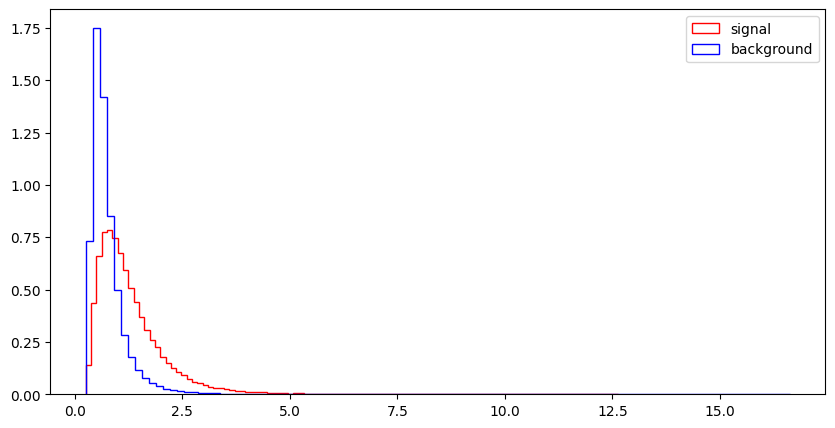

l_1_eta


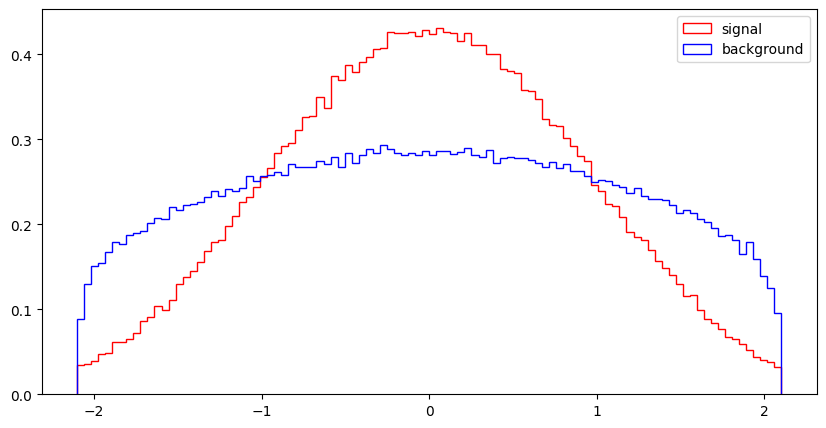

l_1_phi


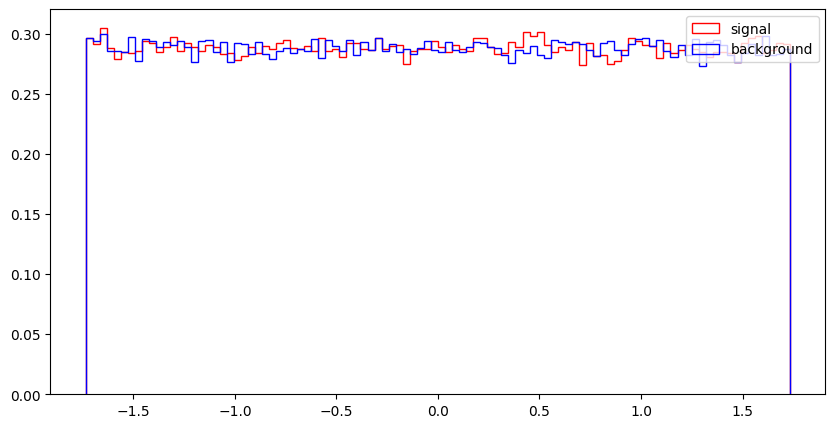

l_2_pT


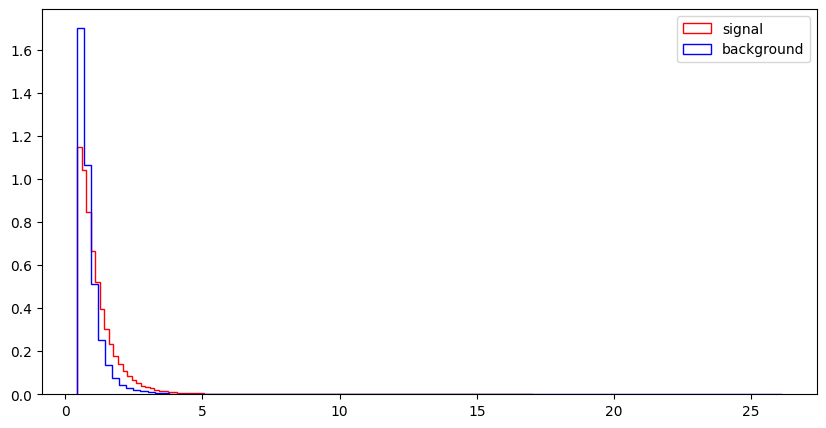

l_2_eta


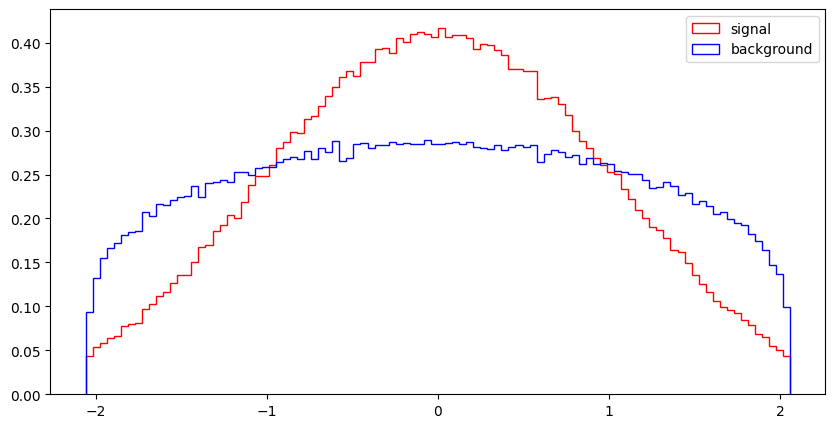

l_2_phi


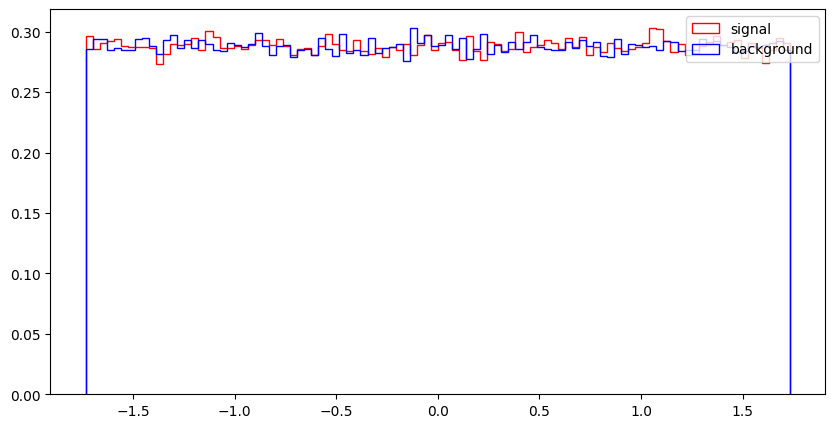

MET


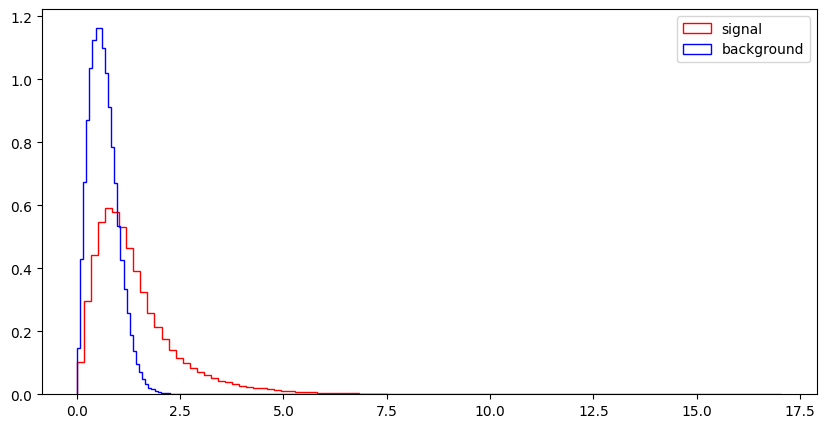

MET_phi


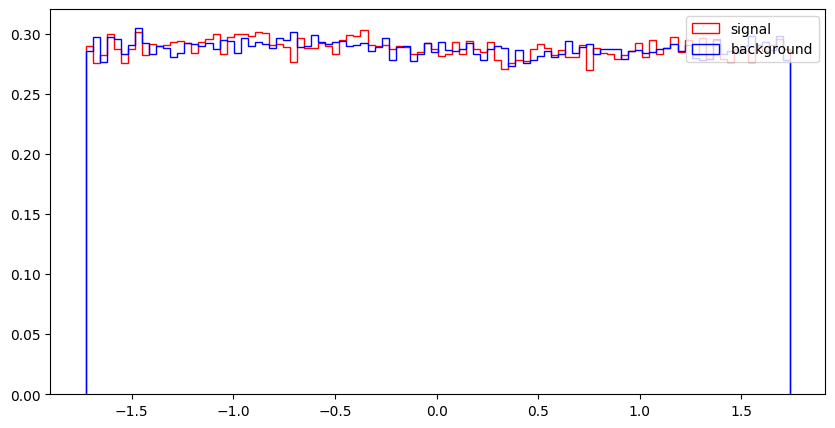

MET_rel


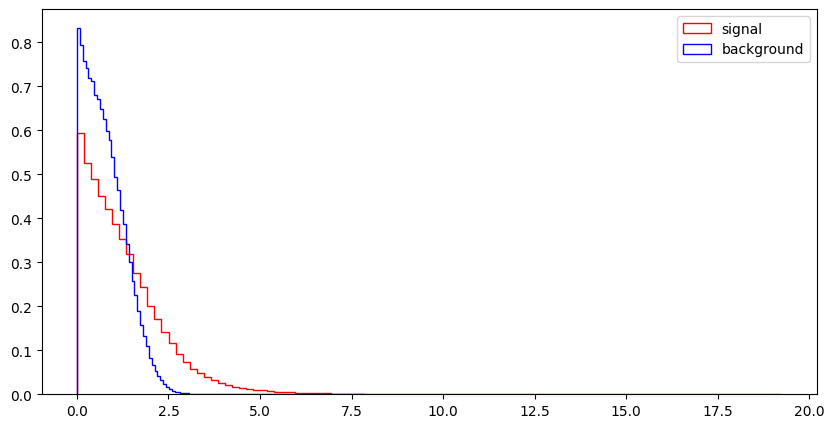

axial_MET


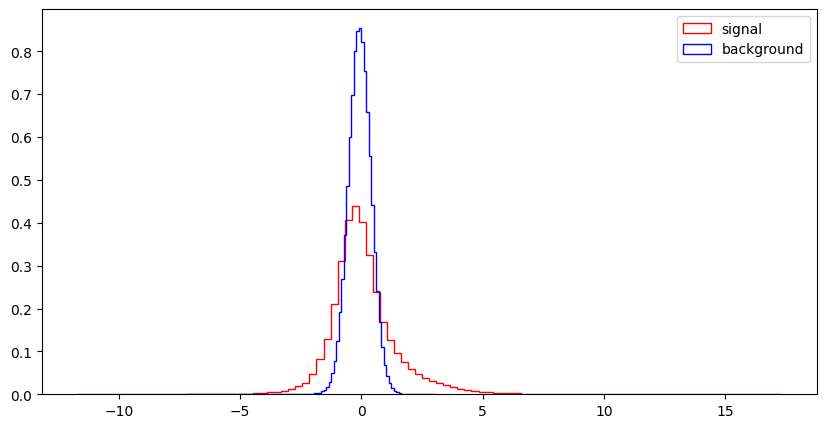

M_R


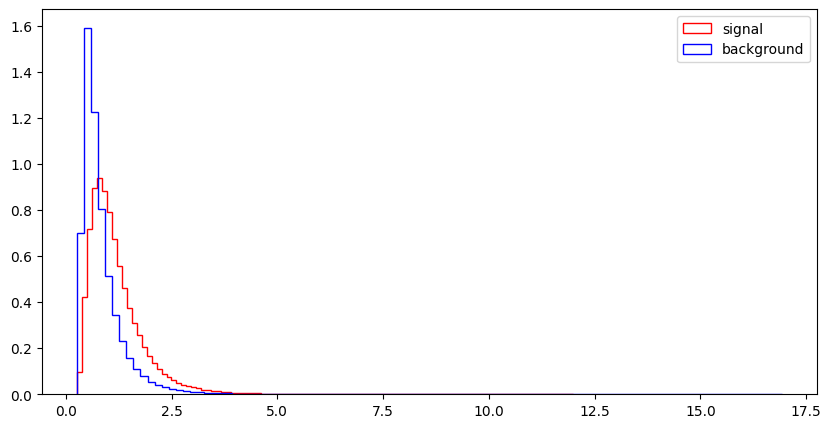

M_TR_2


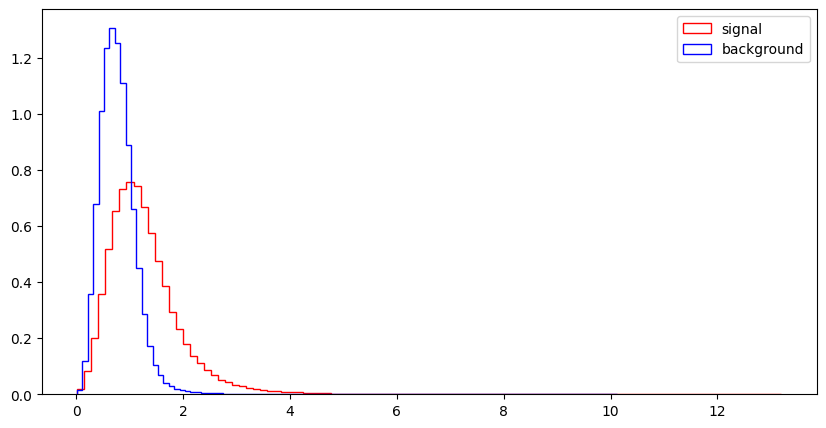

R


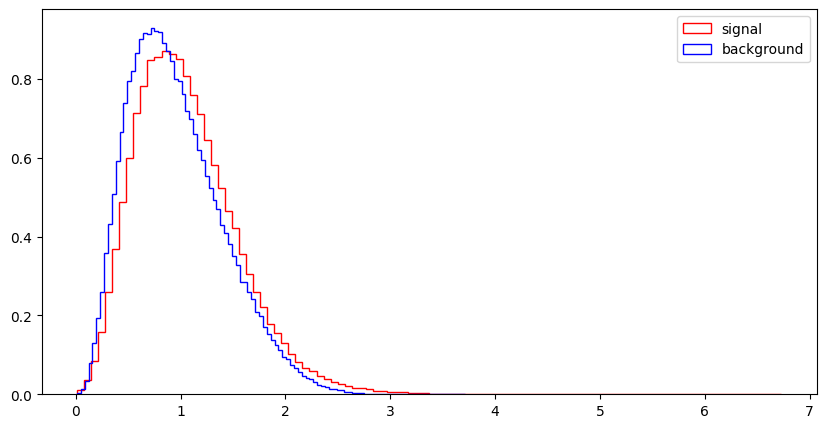

MT2


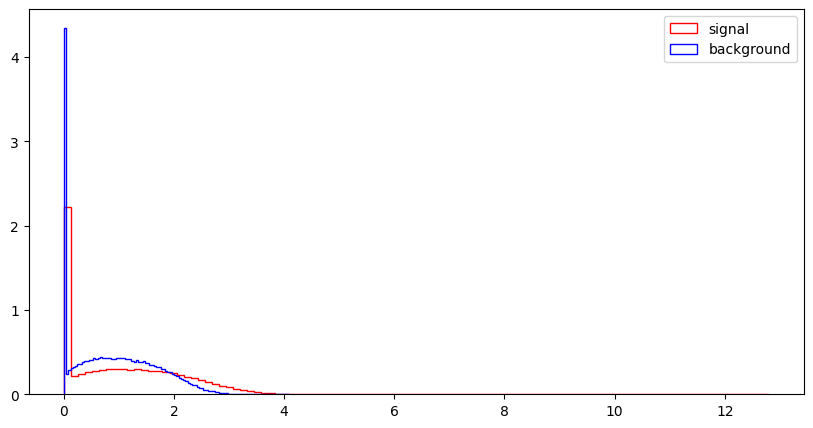

S_R


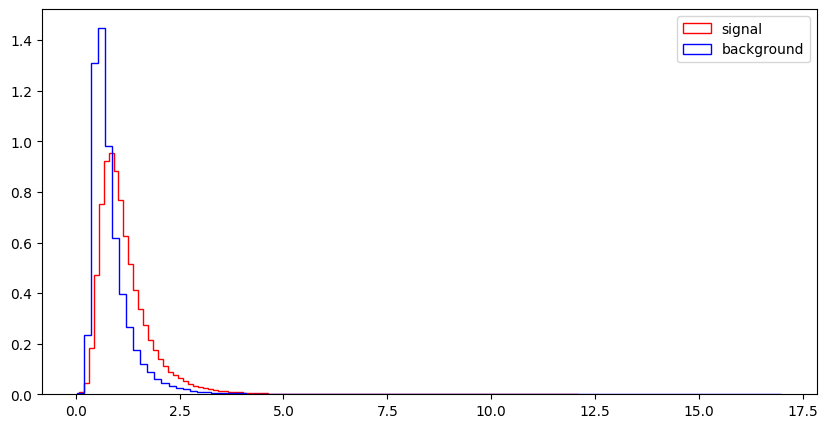

M_Delta_R


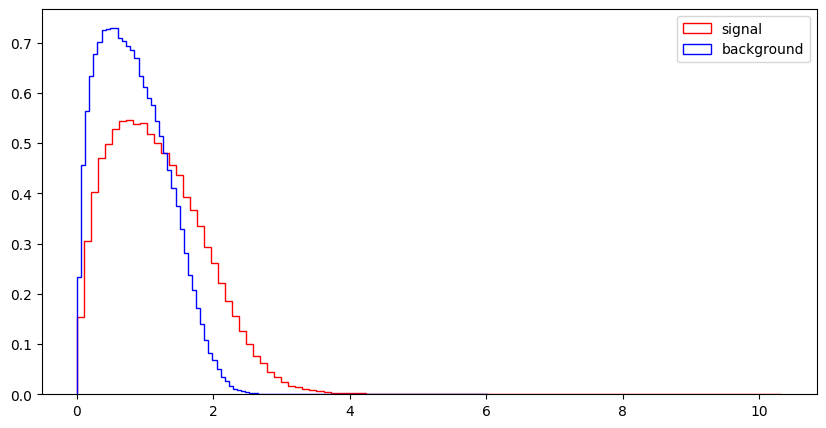

dPhi_r_b


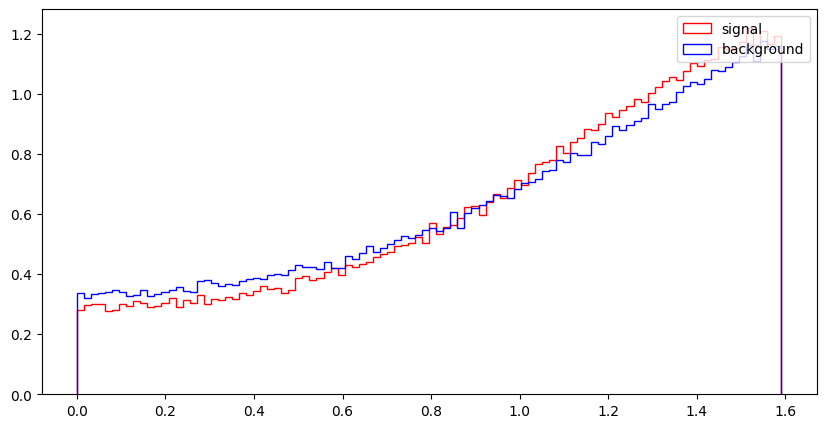

cos_theta_r1


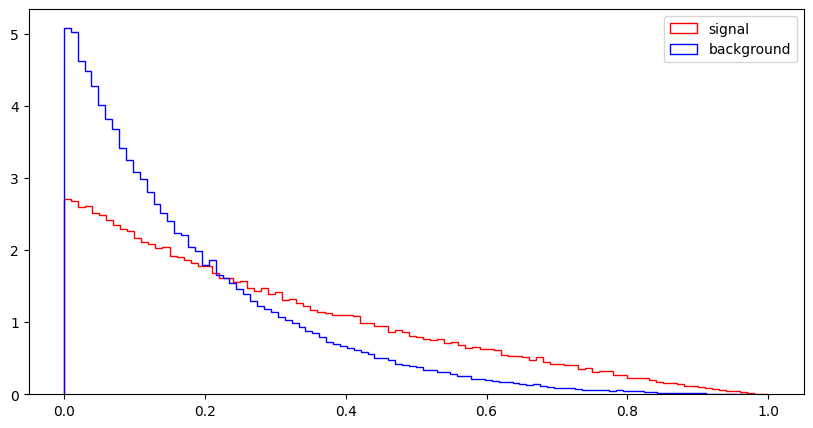

In [25]:
import numpy as np
for var in VarNames[1:]:
    print (var)
    plt.figure(figsize=(10,5))
    plt.hist(np.array(df_sig[var]),bins=100,histtype="step", color="red",label="signal",density=1, stacked=True)
    plt.hist(np.array(df_bkg[var]),bins=100,histtype="step", color="blue", label="background",density=1, stacked=True)
    plt.legend(loc='upper right')
    plt.show()

## Exercise 3: Make nice figures

Now use `matplotlib` to reproduce as closely as you can figures 5 and 6 from the paper. This exercise is intended to get you to familiarize yourself with making nicely formatted `matplotlib` figures with multiple plots. Note that the plots in the paper are actually wrong!

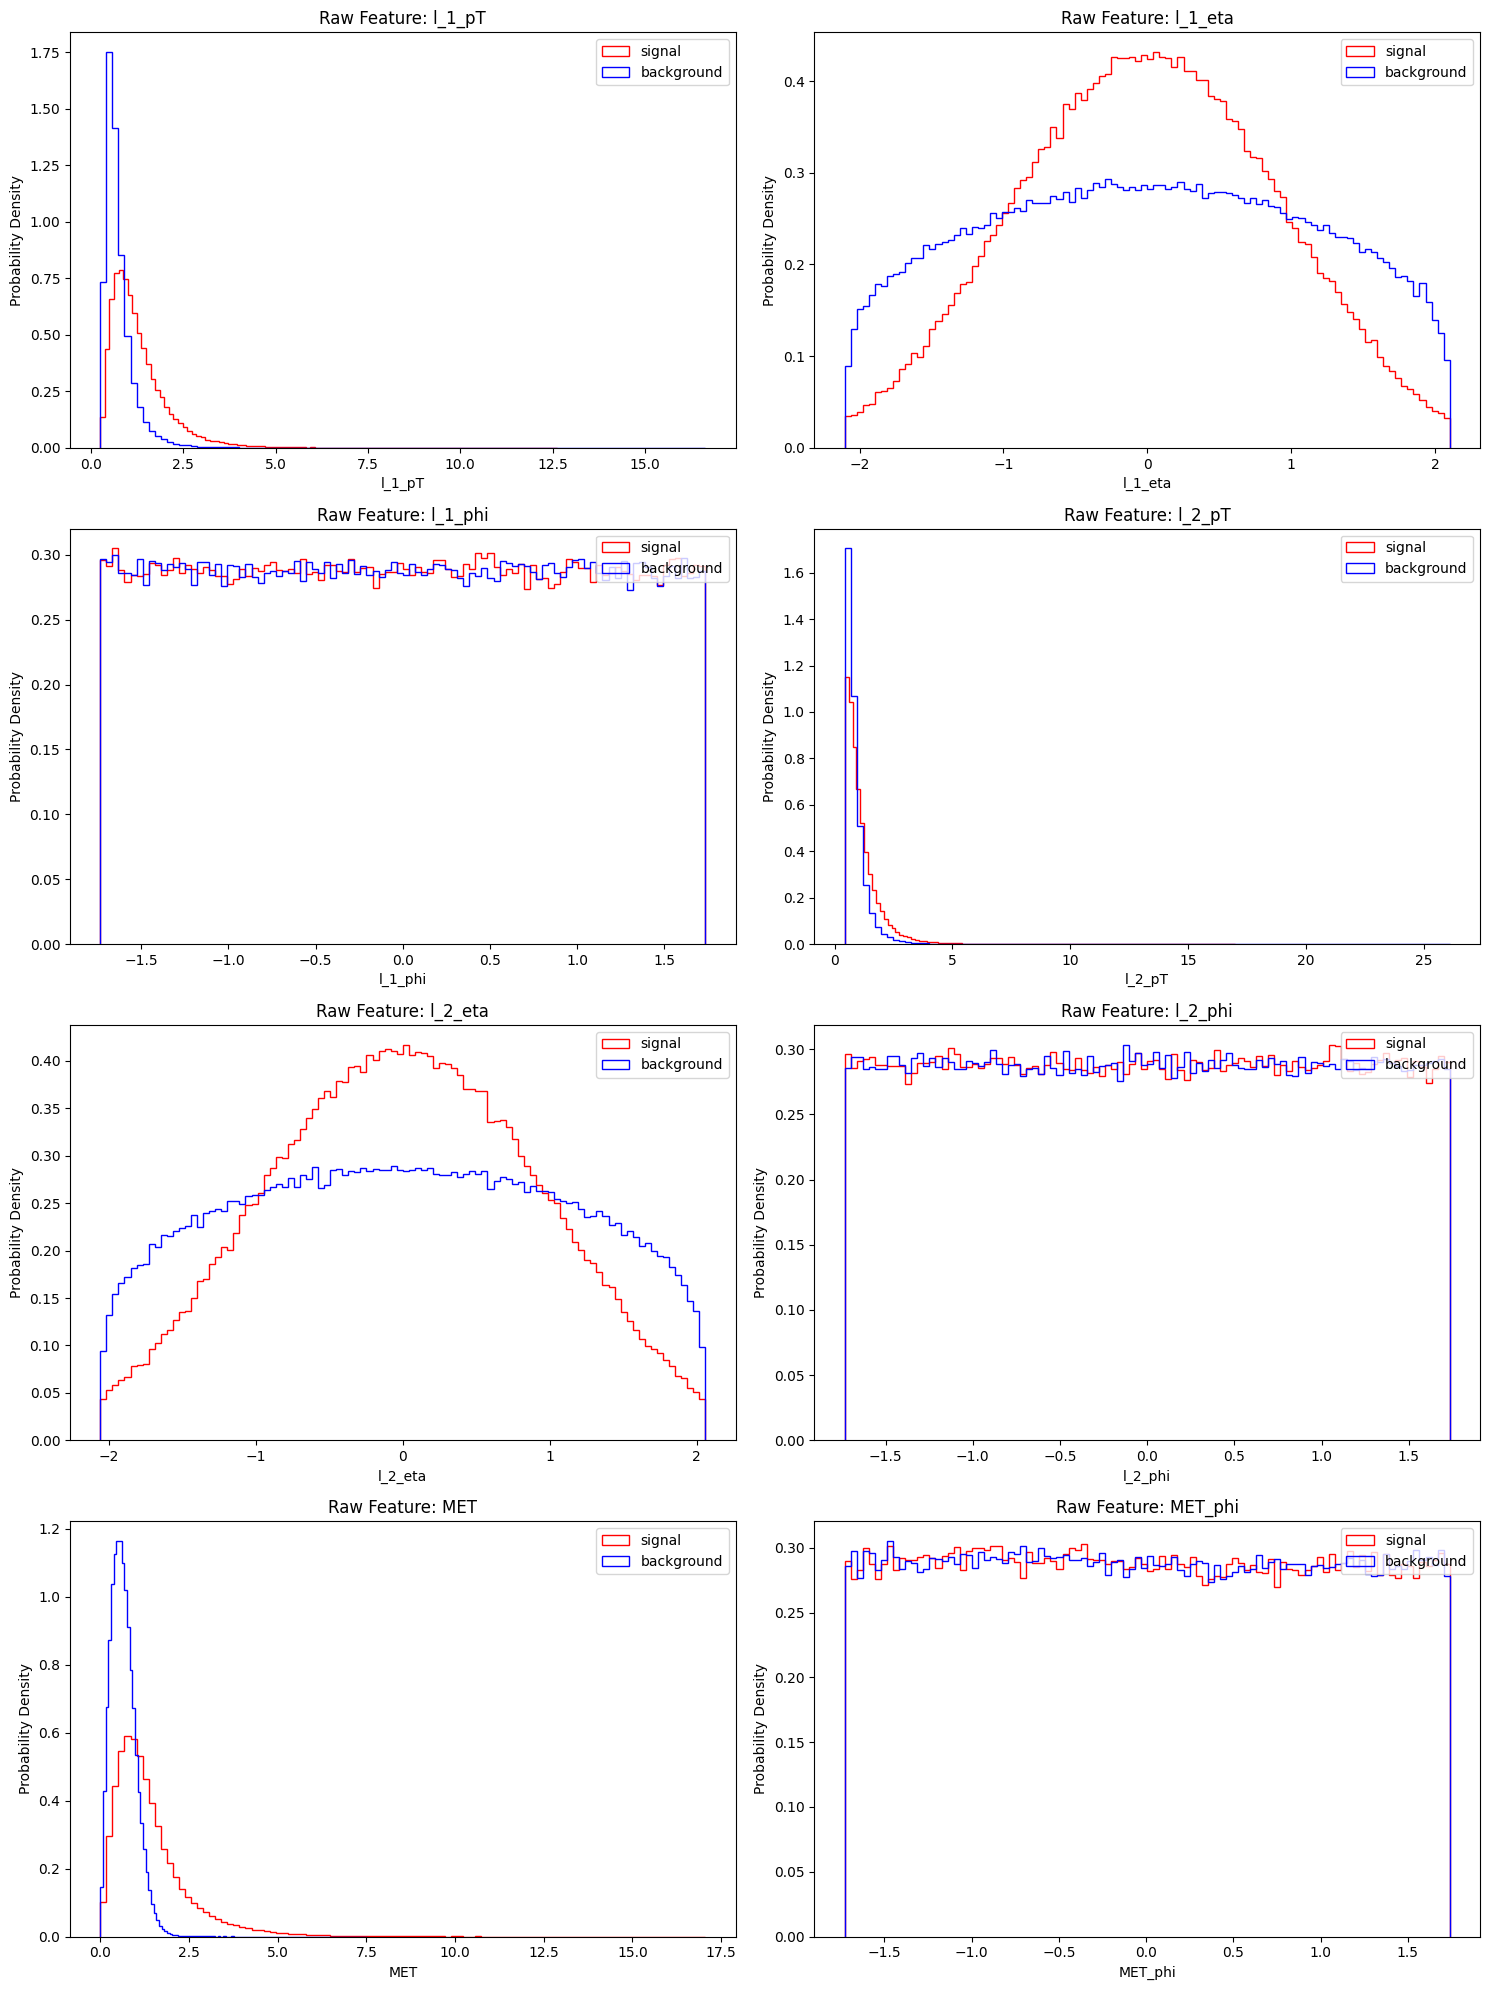

In [26]:
plt.figure(figsize=(15, 20))

for i, var in enumerate(RawNames):
    plt.subplot(4, 2, i + 1)

    plt.hist(np.array(df_sig[var]), bins=100, histtype="step",
             color="red", label="signal", density=1, stacked=True)
    plt.hist(np.array(df_bkg[var]), bins=100, histtype="step",
             color="blue", label="background", density=1, stacked=True)

    plt.title(f"Raw Feature: {var}")
    plt.xlabel(var)
    plt.ylabel("Probability Density")
    plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

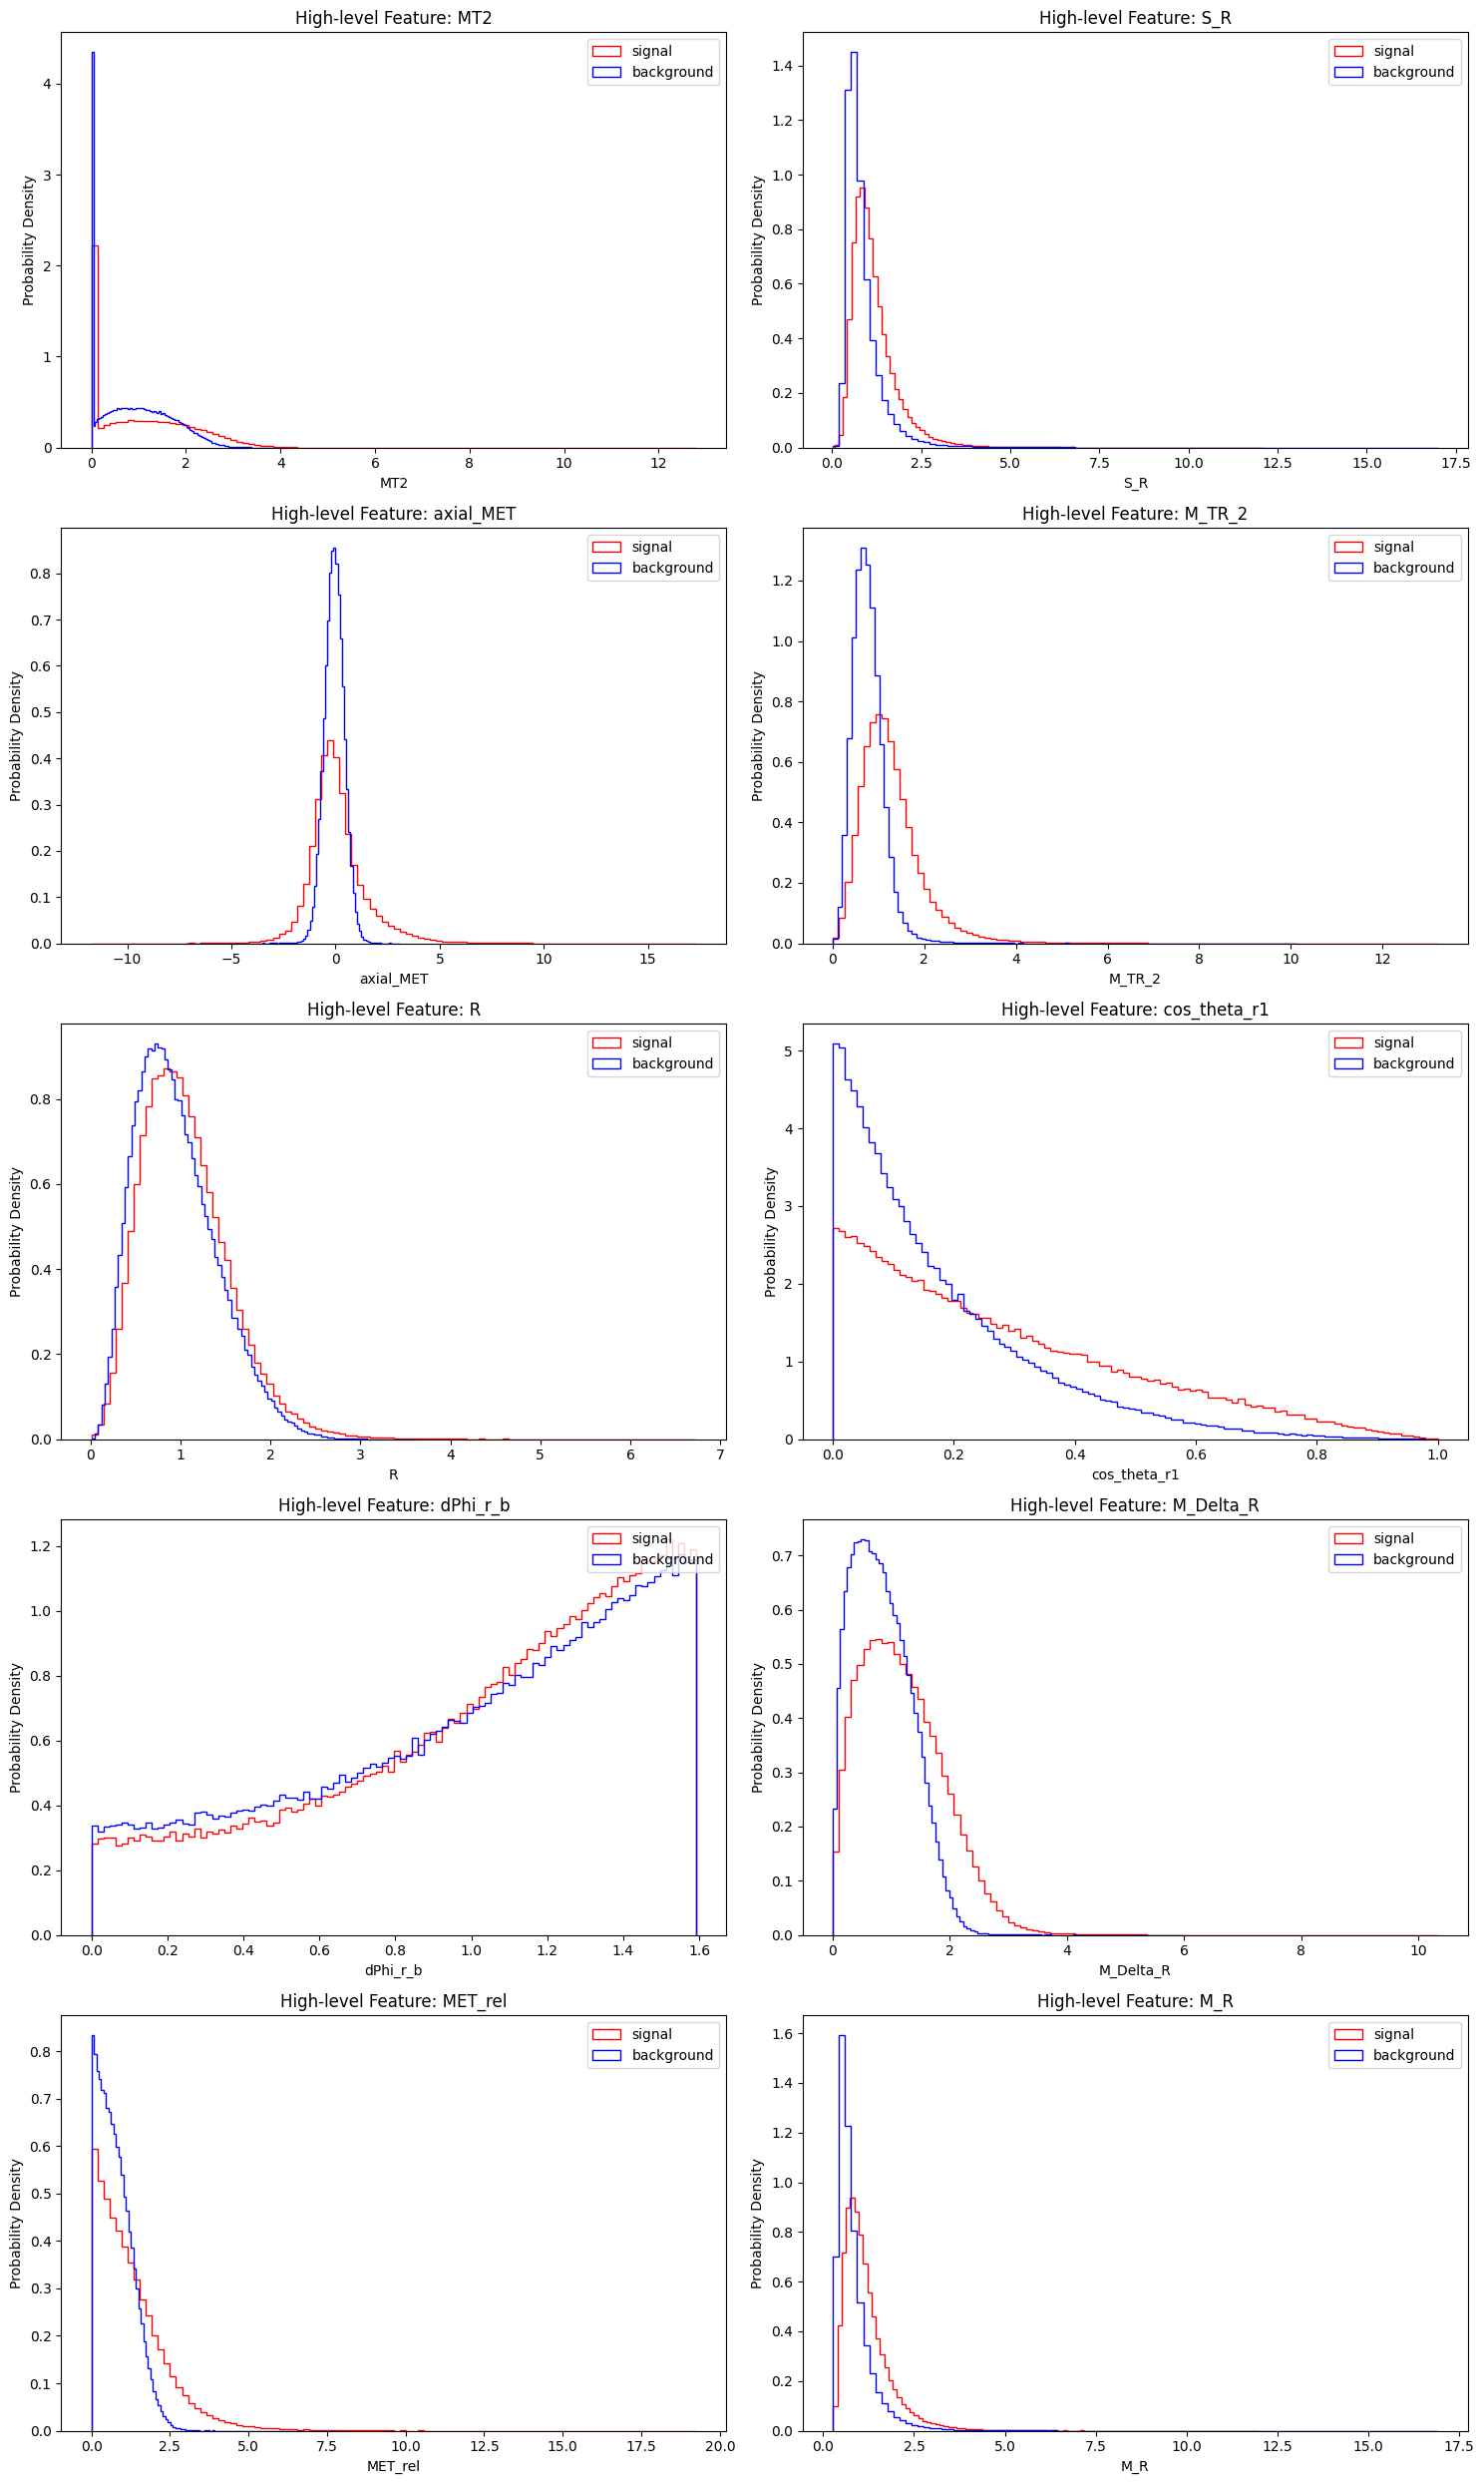

In [27]:
# Figure 6: high-level features in a 5x2 grid
plt.figure(figsize=(15, 25))

for i, var in enumerate(FeatureNames):
    plt.subplot(5, 2, i + 1)

    plt.hist(np.array(df_sig[var]), bins=100, histtype="step",
             color="red", label="signal", density=1, stacked=True)
    plt.hist(np.array(df_bkg[var]), bins=100, histtype="step",
             color="blue", label="background", density=1, stacked=True)

    plt.title(f"High-level Feature: {var}")
    plt.xlabel(var)
    plt.ylabel("Probability Density")
    plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

## Exercise 4: Correlation

### Exercise 4.1

#### Part a
Write a function that creates pair plots and use it to compare variables in the SUSY sample, separately for low and high-level features. Refer to Lecture 13 for details. Do not use `seaborn`.

#### Part b
Making these plots can be slow because creating each plot initiates a full loop over the data. Make at least one modification to your function in part a to speed it up. Can you propose a different method of creating histograms that would speed up making such pair plots?

#### Part c
Which observables appear to be best for separating signal from background?

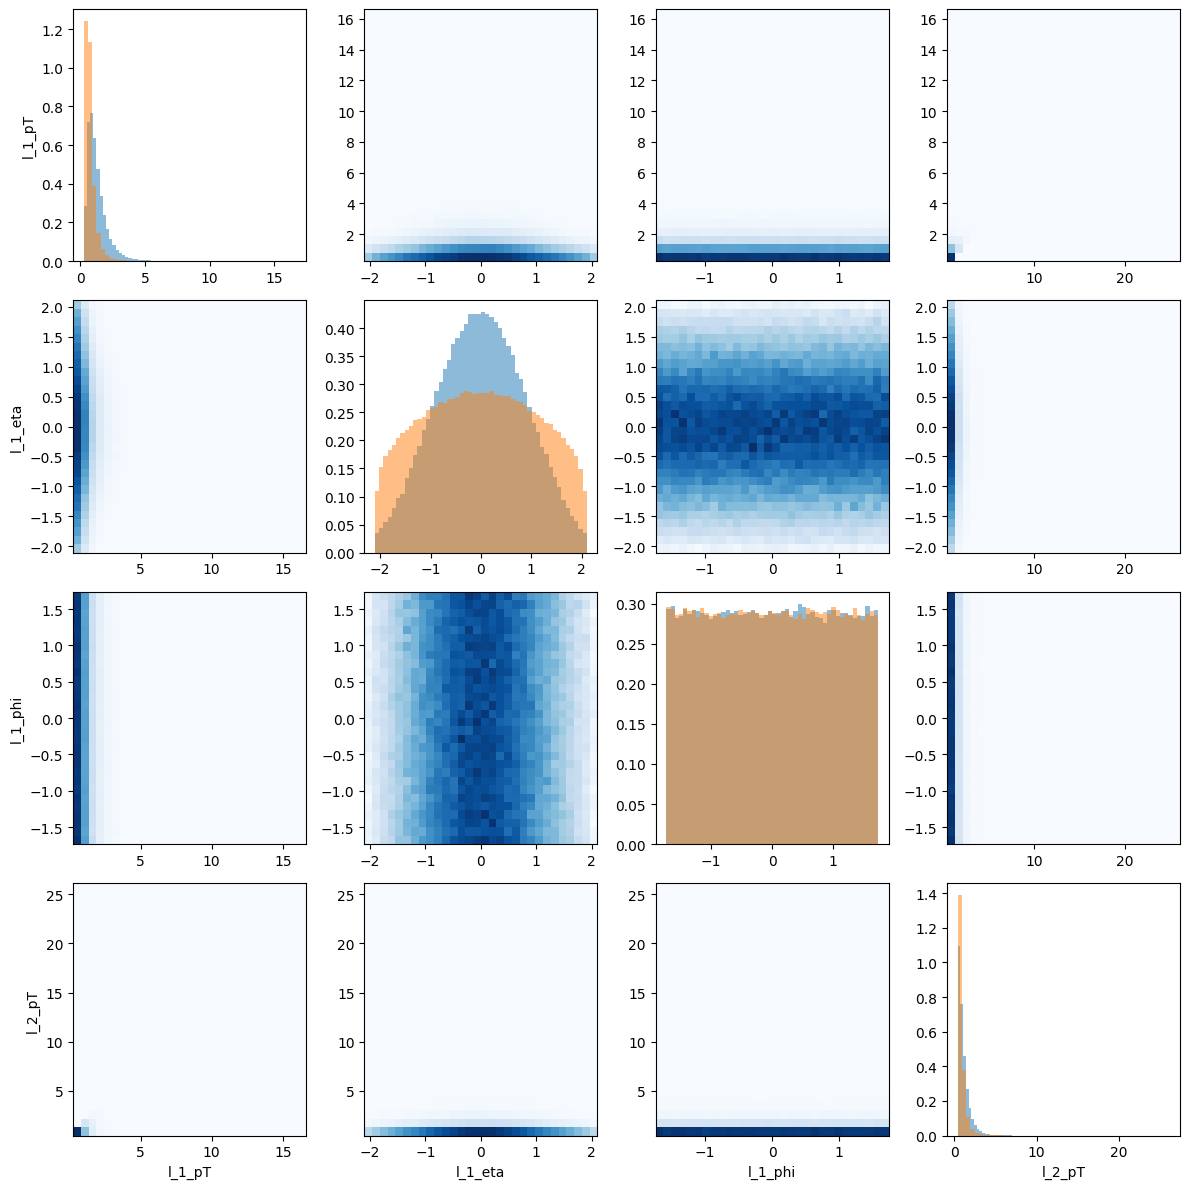

In [28]:
def my_pair_plot(df, variables):
    # Selection dict following the Lecture 13 approach
    selections = {"Signal": df.signal == 1, "Background": df.signal == 0}
    n = len(variables)
    plt.figure(figsize=(n * 3, n * 3))

    plot_idx = 0
    for i, var_y in enumerate(variables):
        for j, var_x in enumerate(variables):
            plot_idx += 1
            plt.subplot(n, n, plot_idx)

            if i == j:
                # Diagonal: 1D histogram to compare shapes
                for label, sel in selections.items():
                    plt.hist(df[sel][var_x], bins=50, alpha=0.5, density=True, label=label)
            else:
                # Off-diagonal: 2D histogram (much faster than scatter for large data)
                plt.hist2d(df[var_x], df[var_y], bins=30, cmap='Blues')

            # Only label outer edges to avoid clutter
            if i == n - 1:
                plt.xlabel(var_x)
            if j == 0:
                plt.ylabel(var_y)

    plt.tight_layout()
    plt.show()

# Test with first 4 raw variables to keep it quick
my_pair_plot(df, RawNames[:4])

**Part b:** The main speed improvement is switching from `plt.scatter` to `plt.hist2d` for off-diagonal plots. `hist2d` pre-bins the data into a grid before rendering, so performance doesn't degrade with large datasets the way scatter does.

**Part c:** From the histograms and pair plots, the high-level features like `MT2` and `M_R` show the clearest separation between signal and background peaks. Raw variables like `l_1_phi` have a lot of overlap and aren't very useful on their own.

### Exercise 4.2

#### Part a
Install [tabulate](https://github.com/astanin/python-tabulate). 

#### Part b
Use numpy to compute the [covariance matrix](https://numpy.org/doc/stable/reference/generated/numpy.cov.html) and [correlation matrix](https://numpy.org/doc/stable/reference/generated/numpy.corrcoef.html) between all observabes, and separately between low and high-level features.

#### Part c
Use tabulate to create a well formatted table of the covariance and correlation matrices, with nice headings and appropriate significant figures. Embed the table into this notebook.

#### Part d
Write a function that takes a dataset and appropriate arguments and performs steps b and c.  

Hint: Example code for embedding a `tabulate` table into a notebook:

In [30]:
!pip install tabulate
from IPython.display import HTML, display
import tabulate
table = [["A",1,2],
        ["C",3,4],
        ["D",5,6]]
display(HTML(tabulate.tabulate(table, tablefmt='html', headers=["X","Y","Z"])))

X,Y,Z
A,1,2
C,3,4
D,5,6


In [31]:
def generate_formatted_matrices(df, variables, group_label):
    """
    Computes and displays covariance and correlation matrices
    as embedded HTML tables using tabulate.
    """
    # Transpose so numpy sees each variable as a row
    data_array = df[variables].values.T

    cov_matrix  = np.cov(data_array)
    corr_matrix = np.corrcoef(data_array)

    def render_as_html_table(matrix, headers, matrix_type):
        print(f"\n>>> {group_label}: {matrix_type}")

        # Round to 3 decimal places for readability
        rounded_data = np.round(matrix, 3).tolist()

        # Add row labels so the table is self-explanatory
        formatted_rows = [[headers[i]] + row for i, row in enumerate(rounded_data)]

        display(HTML(tabulate.tabulate(formatted_rows, tablefmt='html', headers=[""] + headers)))

    render_as_html_table(cov_matrix,  variables, "Covariance Matrix")
    render_as_html_table(corr_matrix, variables, "Correlation Matrix")


generate_formatted_matrices(df, RawNames,     "RAW KINEMATICS")
generate_formatted_matrices(df, FeatureNames, "HIGH-LEVEL FEATURES")


>>> RAW KINEMATICS: Covariance Matrix


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi
l_1_pT,0.467,-0,0,0.305,-0,0.001,0.228,-0.001
l_1_eta,-0,1.004,-0.001,-0,0.408,-0.001,-0.002,-0.001
l_1_phi,0,-0.001,1.004,0.001,0,-0.267,0.001,-0.185
l_2_pT,0.305,-0,0.001,0.425,-0.001,0,0.079,-0.002
l_2_eta,-0,0.408,0,-0.001,1.006,0,0,-0
l_2_phi,0.001,-0.001,-0.267,0,0,1.004,-0,-0.035
MET,0.228,-0.002,0.001,0.079,0,-0,0.762,-0.003
MET_phi,-0.001,-0.001,-0.185,-0.002,-0,-0.035,-0.003,1.003



>>> RAW KINEMATICS: Correlation Matrix


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi
l_1_pT,1,-0.001,0,0.684,-0.001,0.001,0.383,-0.001
l_1_eta,-0.001,1,-0.001,-0,0.406,-0.001,-0.002,-0.001
l_1_phi,0,-0.001,1,0.002,0,-0.266,0.001,-0.184
l_2_pT,0.684,-0,0.002,1,-0.001,0,0.14,-0.002
l_2_eta,-0.001,0.406,0,-0.001,1,0,0,-0
l_2_phi,0.001,-0.001,-0.266,0,0,1,-0,-0.035
MET,0.383,-0.002,0.001,0.14,0,-0,1,-0.003
MET_phi,-0.001,-0.001,-0.184,-0.002,-0,-0.035,-0.003,1



>>> HIGH-LEVEL FEATURES: Covariance Matrix


,MT2,S_R,axial_MET,M_TR_2,R,cos_theta_r1,dPhi_r_b,M_Delta_R,MET_rel,M_R
MT2,0.738,-0.011,-0.461,0.189,0.232,0.045,0.021,0.433,0.409,-0.037
S_R,-0.011,0.382,-0.041,0.228,-0.083,-0.01,-0.003,0.096,0.082,0.38
axial_MET,-0.461,-0.041,1.005,-0.185,-0.181,-0.054,-0.025,-0.233,-0.12,0.017
M_TR_2,0.189,0.228,-0.185,0.338,0.104,0.052,0.058,0.242,0.302,0.21
R,0.232,-0.083,-0.181,0.104,0.222,0.058,0.087,0.165,0.249,-0.113
cos_theta_r1,0.045,-0.01,-0.054,0.052,0.058,0.039,0.009,0.039,0.055,-0.014
dPhi_r_b,0.021,-0.003,-0.025,0.058,0.087,0.009,0.19,0.042,0.146,-0.029
M_Delta_R,0.433,0.096,-0.233,0.242,0.165,0.039,0.042,0.389,0.415,0.074
MET_rel,0.409,0.082,-0.12,0.302,0.249,0.055,0.146,0.415,0.79,0.044
M_R,-0.037,0.38,0.017,0.21,-0.113,-0.014,-0.029,0.074,0.044,0.392



>>> HIGH-LEVEL FEATURES: Correlation Matrix


,MT2,S_R,axial_MET,M_TR_2,R,cos_theta_r1,dPhi_r_b,M_Delta_R,MET_rel,M_R
MT2,1,-0.021,-0.535,0.379,0.574,0.264,0.056,0.809,0.535,-0.068
S_R,-0.021,1,-0.067,0.635,-0.287,-0.085,-0.013,0.249,0.15,0.981
axial_MET,-0.535,-0.067,1,-0.317,-0.383,-0.272,-0.057,-0.373,-0.134,0.027
M_TR_2,0.379,0.635,-0.317,1,0.38,0.451,0.229,0.668,0.584,0.577
R,0.574,-0.287,-0.383,0.38,1,0.627,0.424,0.564,0.595,-0.383
cos_theta_r1,0.264,-0.085,-0.272,0.451,0.627,1,0.106,0.319,0.316,-0.116
dPhi_r_b,0.056,-0.013,-0.057,0.229,0.424,0.106,1,0.155,0.378,-0.106
M_Delta_R,0.809,0.249,-0.373,0.668,0.564,0.319,0.155,1,0.748,0.189
MET_rel,0.535,0.15,-0.134,0.584,0.595,0.316,0.378,0.748,1,0.078
M_R,-0.068,0.981,0.027,0.577,-0.383,-0.116,-0.106,0.189,0.078,1


I used `.values.T` to correctly orient the data for `np.corrcoef` and `np.cov`. Wrapping everything in `generate_formatted_matrices` keeps the rounding, labeling, and HTML rendering consistent across both feature groups. I picked 3 decimal places as a balance between precision and readability. The diagonal of 1.0 in the correlation matrix confirms the calculation is correct.

## Exercise 5: Selection

### Exercise 5.1

Part a
By looking at the signal/background distributions for each observable (e.g. $x$) determine which selection criteria would be optimal: 

1. $x > x_c$
2. $x < x_c$
3. $|x - \mu| > x_c$
4. $|x - \mu| < x_c$

where $x_c$ is value to be determined below.

### Exercise 5.2

Plot the True Positive Rate (TPR) (aka signal efficiency $\epsilon_S(x_c)$) and False Positive Rate (FPR) (aka background efficiency $\epsilon_B(x_c)$) as function of $x_c$ for applying the strategy in part a to each observable. 

### Exercise 5.3
Assume 3 different scenarios corresponding to different numbers of signal and background events expected in data:

1. Expect $N_S=10$, $N_B=100$.
1. Expect $N_S=100$, $N_B=1000$.
1. Expect $N_S=1000$, $N_B=10000$.
1. Expect $N_S=10000$, $N_B=100000$.

Plot the significance ($\sigma_{S'}$) for each observable as function of $x_c$ for each scenario, where 

$\sigma_{S'}= \frac{N'_S}{\sqrt{N'_S+N'_B}}$

and $N'_{S,B} = \epsilon_{S,B}(x_c) * N_{S,B}$.

In [32]:
# 5.1: Assign cut direction for each variable
# 1 = x > xc, -1 = x < xc (based on where the signal peak sits)
cut_directions = {
    "l_1_pT": 1, "l_2_pT": 1, "MET": 1, "MT2": 1, "M_R": 1, "S_R": 1,
    "M_Delta_R": 1, "MET_rel": 1, "M_TR_2": 1, "axial_MET": -1
}

# Default to 1 for anything not explicitly listed
for var in VarNames[1:]:
    if var not in cut_directions:
        cut_directions[var] = 1

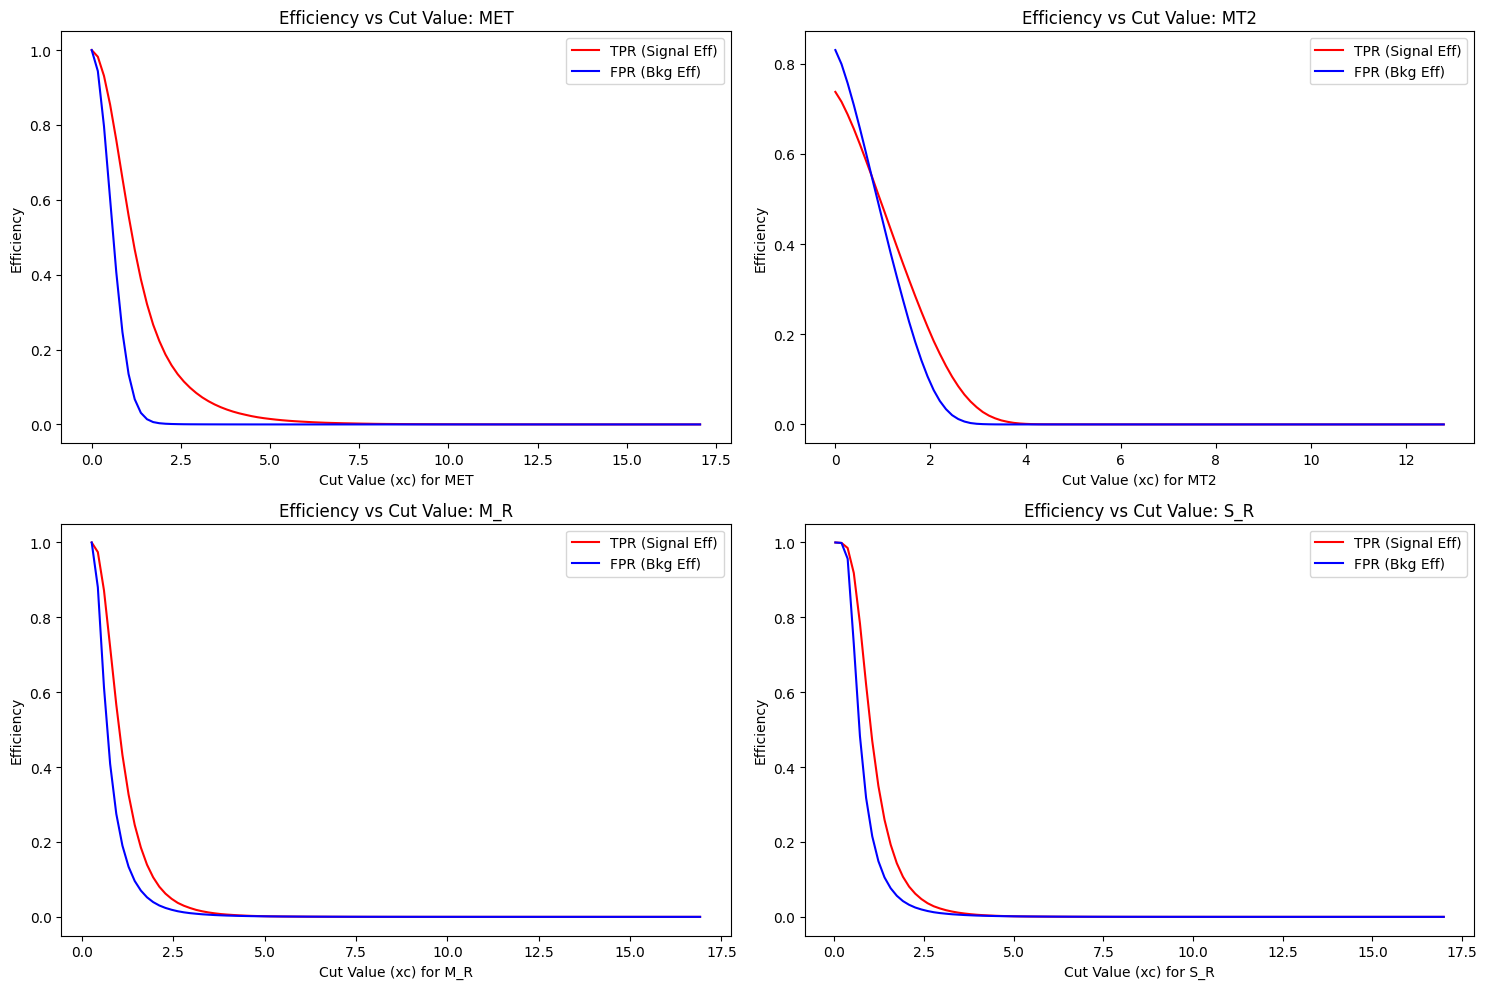

In [33]:
# 5.2: Function to compute TPR and FPR across a range of cut values
def calculate_efficiencies(df_sig, df_bkg, var, direction):
    # Combine both classes to get the full range of cut values
    all_values = np.concatenate([df_sig[var], df_bkg[var]])
    min_val, max_val = np.min(all_values), np.max(all_values)
    xc_values = np.linspace(min_val, max_val, 100)

    tpr_list = []
    fpr_list = []

    for xc in xc_values:
        if direction == 1:
            # Vectorized boolean sums — much faster than looping over events
            tpr = np.sum(df_sig[var] > xc) / len(df_sig)
            fpr = np.sum(df_bkg[var] > xc) / len(df_bkg)
        else:
            tpr = np.sum(df_sig[var] < xc) / len(df_sig)
            fpr = np.sum(df_bkg[var] < xc) / len(df_bkg)

        tpr_list.append(tpr)
        fpr_list.append(fpr)

    return xc_values, np.array(tpr_list), np.array(fpr_list)


# Plot efficiencies for the 4 most promising variables
plt.figure(figsize=(15, 10))
target_vars = ["MET", "MT2", "M_R", "S_R"]

for i, var in enumerate(target_vars):
    plt.subplot(2, 2, i + 1)
    xc, tpr, fpr = calculate_efficiencies(df_sig, df_bkg, var, cut_directions[var])

    plt.plot(xc, tpr, color='red',  label='TPR (Signal Eff)')
    plt.plot(xc, fpr, color='blue', label='FPR (Bkg Eff)')
    plt.title(f"Efficiency vs Cut Value: {var}")
    plt.xlabel(f"Cut Value (xc) for {var}")
    plt.ylabel("Efficiency")
    plt.legend()

plt.tight_layout()
plt.show()

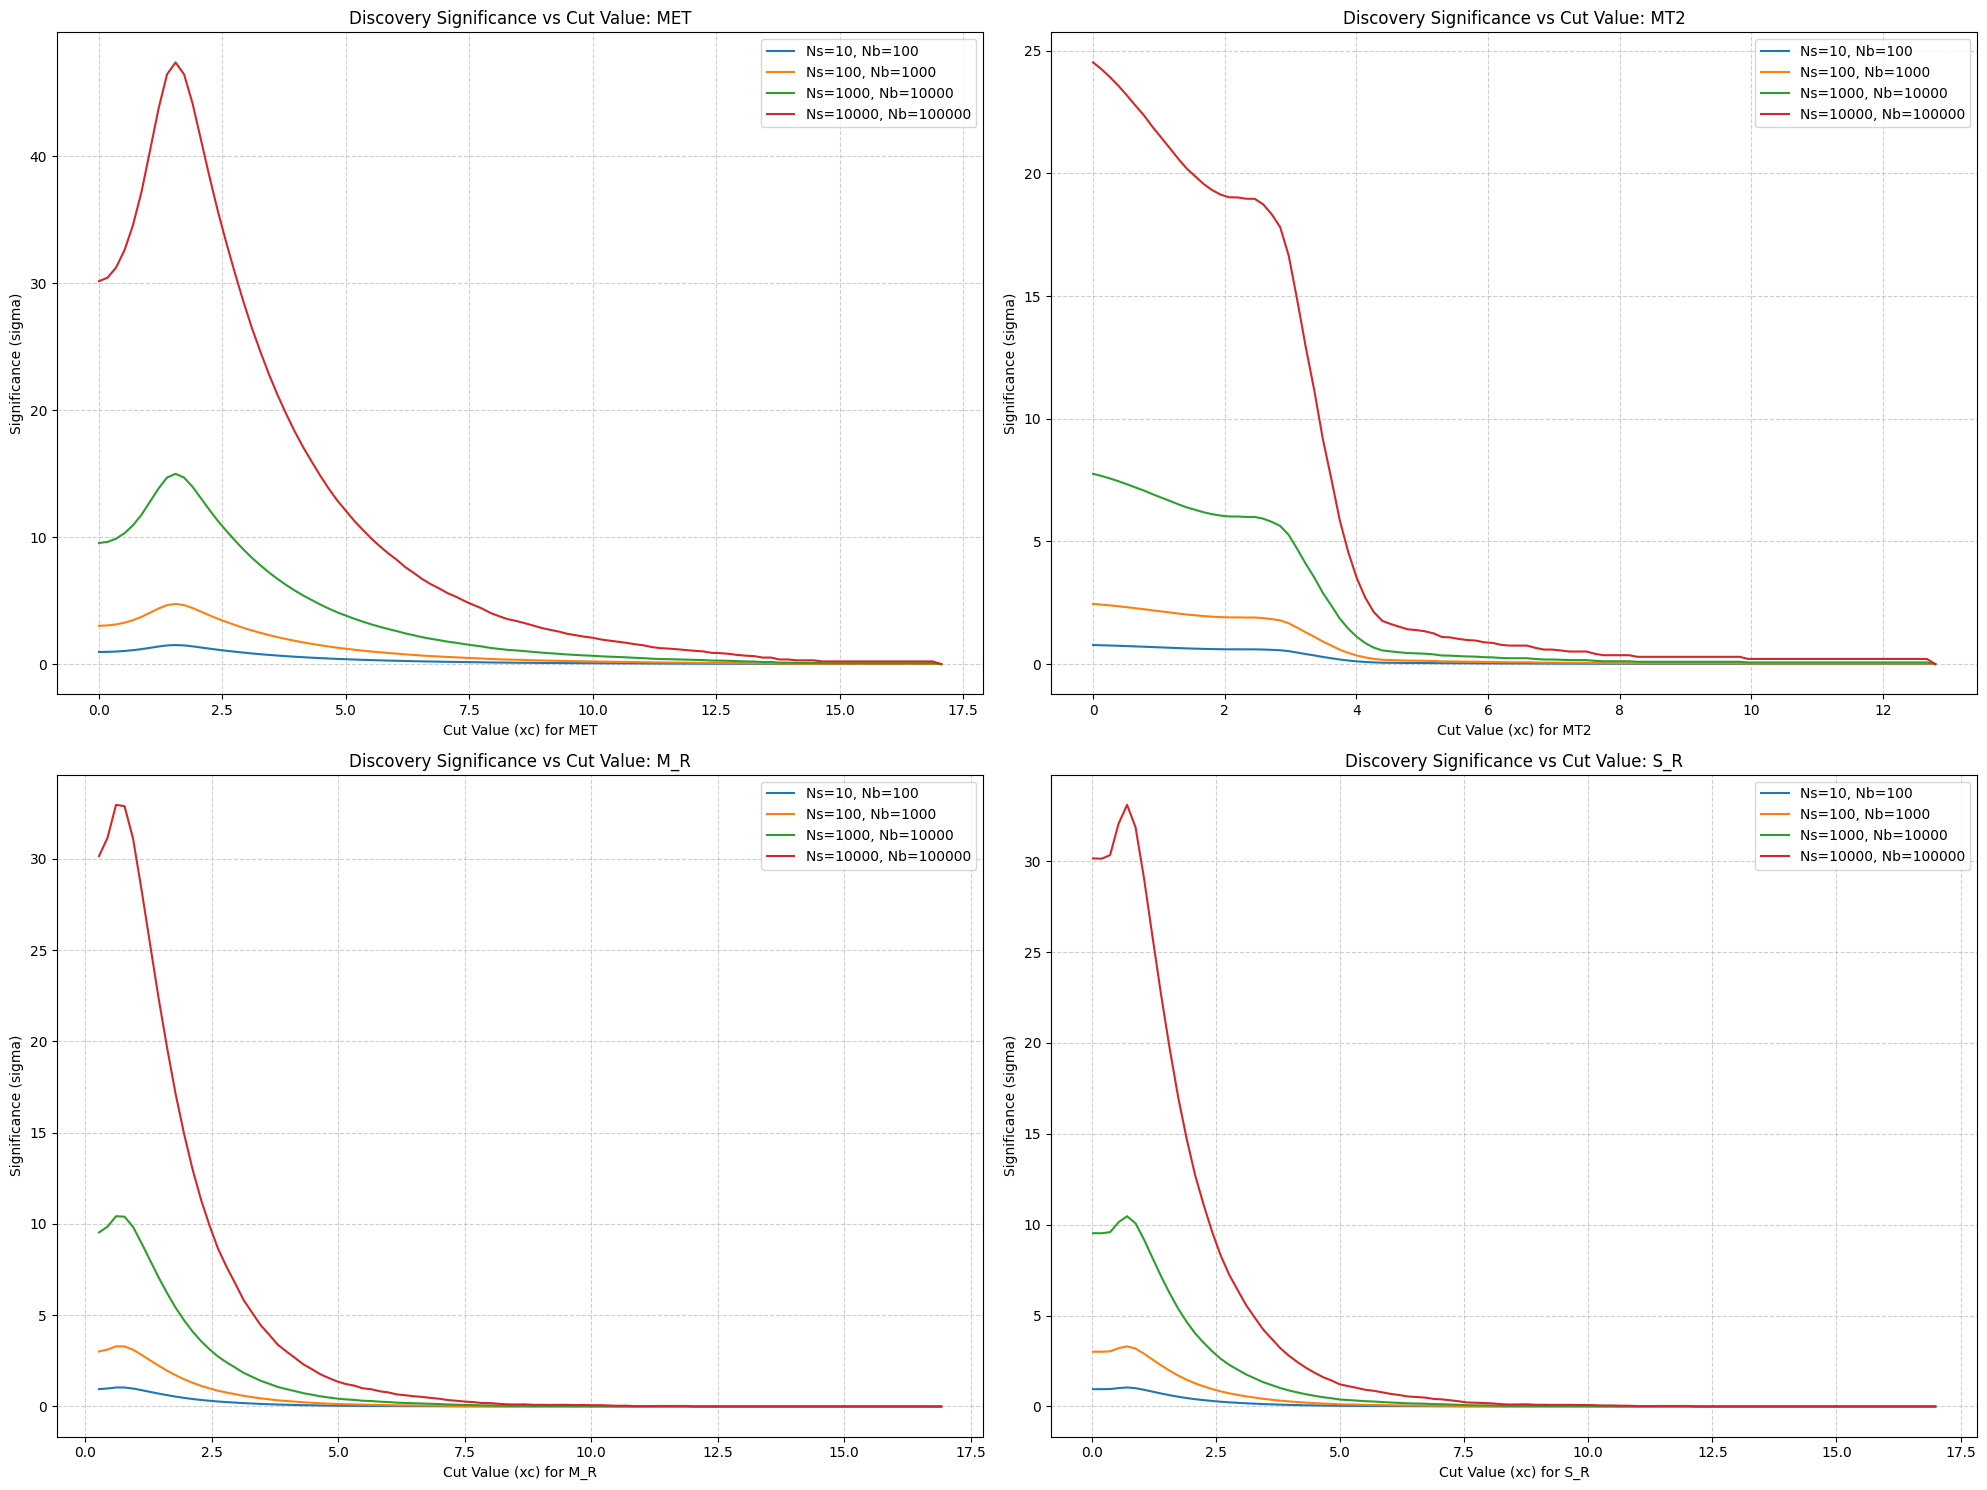

In [34]:
# 5.3: Significance vs cut value for each luminosity scenario
scenarios = [
    {"Ns": 10,    "Nb": 100},
    {"Ns": 100,   "Nb": 1000},
    {"Ns": 1000,  "Nb": 10000},
    {"Ns": 10000, "Nb": 100000}
]

plt.figure(figsize=(20, 15))

for i, var in enumerate(target_vars):
    plt.subplot(2, 2, i + 1)
    xc_vals, tpr, fpr = calculate_efficiencies(df_sig, df_bkg, var, cut_directions[var])

    for s in scenarios:
        Ns, Nb = s["Ns"], s["Nb"]
        Ns_prime = tpr * Ns
        Nb_prime = fpr * Nb

        # Small epsilon prevents division by zero at extreme cut values
        significance = Ns_prime / np.sqrt(Ns_prime + Nb_prime + 1e-10)
        plt.plot(xc_vals, significance, label=f"Ns={Ns}, Nb={Nb}")

    plt.title(f"Discovery Significance vs Cut Value: {var}")
    plt.xlabel(f"Cut Value (xc) for {var}")
    plt.ylabel("Significance (sigma)")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

plt.tight_layout()
plt.show()

## Exercise 6: Cut Flow


### Exercise 6.1

For each above scenario, choose a subset (minumum 3) of observables to use for selections, and values of $x_c$ based on your significance plots (part 3c). 

### Exercise 6.2
Create a "cut-flow" table for each scenario where you successively make the selections on each observable and tabulate $\epsilon_S$, $\epsilon_B$, $N'_S$, $N'_B$, and $\sigma_{S'}$.

### Exercise 6.3
In 3c above you computed the significance for each observable assuming to make no other selections on any other observable. If the variables are correlated, then this assumption can lead to non-optimial results when selecting on multiple variables. By looking at the correlation matrices and your answers to 4b, identify where this effect could be most detrimental to the significance. Attempt to correct the issue by applying the selection in one observable and then optimizing (part 3c) for a second observable. What happens if you change the order of your selection (make selection on second and optimize on first)?




**6.1 - Selected cuts:**

**MT2, xc = 0.8** - Significance peaks consistently around this value. MT2 is a strong SUSY indicator that bounds invisible particle mass.
**MET, xc = 1.25** - Sharp peak here. Standard Model events tend to have low MET, so this cut removes a lot of background.
**M_R, xc = 1.0** - Clear peak, especially in low-luminosity scenarios. Adds a useful mass-scale filter as a third cut.

In [37]:
# 6.2: Cut-flow table for each scenario
my_cuts = [
    {"var": "MT2", "xc": 0.8,  "dir": 1},
    {"var": "MET", "xc": 1.25, "dir": 1},
    {"var": "M_R", "xc": 1.0,  "dir": 1}
]

def run_physics_cut_flow(df, scenarios):
    """
    Applies successive cuts and prints a formatted table of
    efficiencies, yields, and significance for each scenario.
    """
    for s in scenarios:
        Ns_init, Nb_init = s["Ns"], s["Nb"]
        print(f"\n{'='*60}\nCALCULATING CUT FLOW: Ns={Ns_init}, Nb={Nb_init}\n{'='*60}")

        current_sig_df = df[df.signal == 1]
        current_bkg_df = df[df.signal == 0]

        initial_sig_count = len(current_sig_df)
        initial_bkg_count = len(current_bkg_df)

        table_rows = []

        for cut in my_cuts:
            var, xc = cut["var"], cut["xc"]

            # Each cut is applied to the survivors of the previous step
            if cut["dir"] == 1:
                current_sig_df = current_sig_df[current_sig_df[var] > xc]
                current_bkg_df = current_bkg_df[current_bkg_df[var] > xc]
            else:
                current_sig_df = current_sig_df[current_sig_df[var] < xc]
                current_bkg_df = current_bkg_df[current_bkg_df[var] < xc]

            # Cumulative efficiency relative to the full starting sample
            eps_s = len(current_sig_df) / initial_sig_count
            eps_b = len(current_bkg_df) / initial_bkg_count

            Ns_prime = eps_s * Ns_init
            Nb_prime = eps_b * Nb_init
            signif   = Ns_prime / np.sqrt(Ns_prime + Nb_prime + 1e-10)

            table_rows.append([
                f"After {var} > {xc}",
                np.round(eps_s, 4),
                np.round(eps_b, 4),
                int(Ns_prime),
                int(Nb_prime),
                np.round(signif, 2)
            ])

        headers = ["Selection Step", "eps_S (Eff)", "eps_B (Eff)", "Yield N'S", "Yield N'B", "Significance"]
        display(HTML(tabulate.tabulate(table_rows, tablefmt='html', headers=headers)))


run_physics_cut_flow(df, scenarios)


CALCULATING CUT FLOW: Ns=10, Nb=100


Selection Step,eps_S (Eff),eps_B (Eff),Yield N'S,Yield N'B,Significance
After MT2 > 0.8,0.5404,0.5348,5,53,0.7
After MET > 1.25,0.2585,0.0481,2,4,0.95
After M_R > 1.0,0.1382,0.0144,1,1,0.82



CALCULATING CUT FLOW: Ns=100, Nb=1000


Selection Step,eps_S (Eff),eps_B (Eff),Yield N'S,Yield N'B,Significance
After MT2 > 0.8,0.5404,0.5348,54,534,2.23
After MET > 1.25,0.2585,0.0481,25,48,3.01
After M_R > 1.0,0.1382,0.0144,13,14,2.6



CALCULATING CUT FLOW: Ns=1000, Nb=10000


Selection Step,eps_S (Eff),eps_B (Eff),Yield N'S,Yield N'B,Significance
After MT2 > 0.8,0.5404,0.5348,540,5347,7.04
After MET > 1.25,0.2585,0.0481,258,481,9.5
After M_R > 1.0,0.1382,0.0144,138,143,8.23



CALCULATING CUT FLOW: Ns=10000, Nb=100000


Selection Step,eps_S (Eff),eps_B (Eff),Yield N'S,Yield N'B,Significance
After MT2 > 0.8,0.5404,0.5348,5403,53475,22.27
After MET > 1.25,0.2585,0.0481,2584,4812,30.05
After M_R > 1.0,0.1382,0.0144,1382,1436,26.03


**6.3:**
With help of claude and GPT,
Looking at the cut-flow results, adding the third cut (`M_R > 1.0`) actually drops the significance compared to after the second cut. The correlation matrix from Exercise 4.2 explains this  `M_R` is strongly correlated with `S_R` (~0.98) and also shows notable correlation with `MT2`. Once the first two cuts have filtered the data, the surviving events are already partially separated along the `M_R` axis, so the third cut removes more signal than useful background.

The fix is to re-optimize each variable after the previous cut rather than using the standalone peaks from Exercise 5.3. For example, after applying `MT2 > 0.8`, re-scanning MET on those survivors typically gives a looser optimal `xc` because the sample is already cleaner.

Changing the order, cutting on `M_R` first and optimizing `MT2` second, produces the same final set of surviving events, so the overall end significance is the same. The difference is only in how much each step appears to contribute: whichever variable goes first looks like the most powerful one. This is why it makes sense to start with the strongest, least-correlated variable.

## Exercise 7: ROC Curves

### Exercise 7.1
For the top 3 observables you identified earlier, create one figure overlaying the Reciever Operating Characteristic (ROC) curves for the 3 observables. Compute the area under the curves and report it in the legend of the figure.

### Exercise 7.2
Write a function that you can use to quickly create the figure in part a with other observables and different conditions. Note that you will likely revise this function as you do the remainder of the lab.

### Exercise 7.3
Use the function from part b to compare the ROC curves for the successive selections in lab 3, exercise 4. Specifically, plot the ROC curve after each selection.

### Exercise 7.4
Use your function and appropriate example to demonstrate the effect (if any) of changing order of the successive selections.



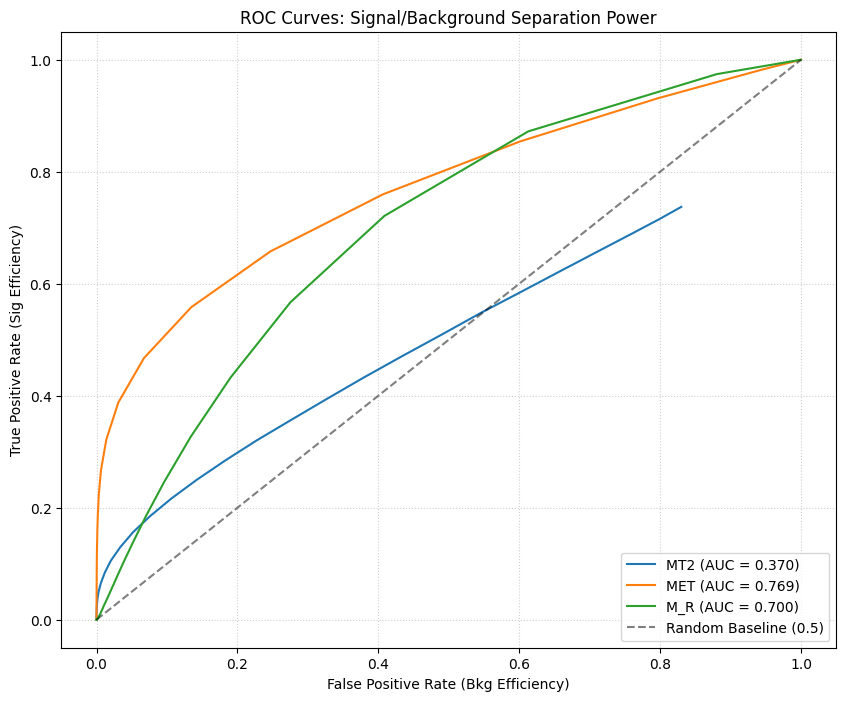

In [38]:
# 7.1: ROC curves for the top 3 observables
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 8))

top_vars = ["MT2", "MET", "M_R"]

for var in top_vars:
    xc, tpr, fpr = calculate_efficiencies(df_sig, df_bkg, var, cut_directions[var])

    # np.trapezoid is the updated name in NumPy 2.0; fall back to np.trapz for older versions
    try:
        auc_val = np.abs(np.trapezoid(tpr, fpr))
    except AttributeError:
        auc_val = np.abs(np.trapz(tpr, fpr))

    plt.plot(fpr, tpr, label=f"{var} (AUC = {auc_val:.3f})")

# Random-guess baseline
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Baseline (0.5)')

plt.title("ROC Curves: Signal/Background Separation Power")
plt.xlabel("False Positive Rate (Bkg Efficiency)")
plt.ylabel("True Positive Rate (Sig Efficiency)")
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right')
plt.show()

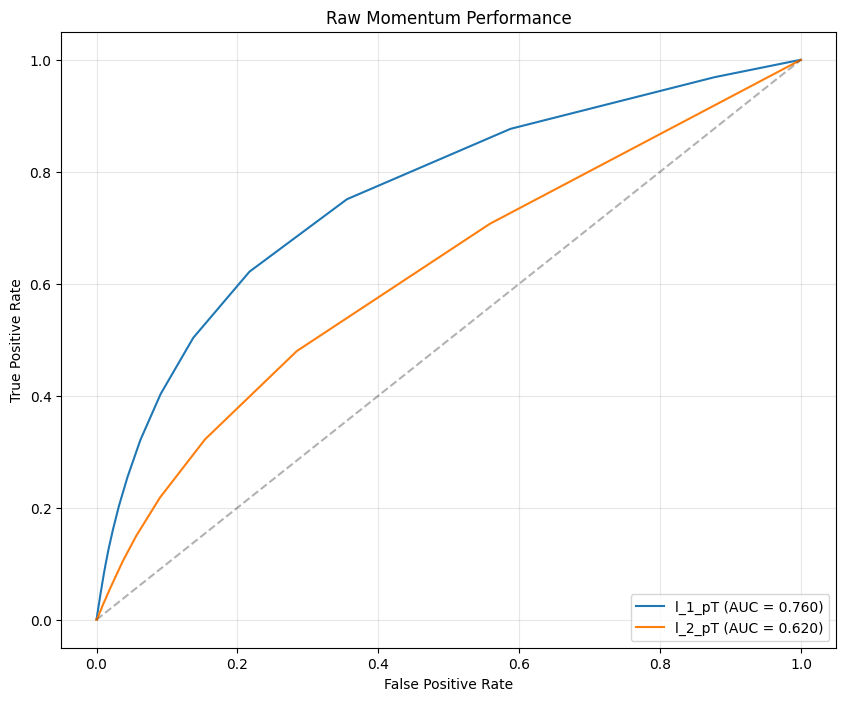

In [39]:
# 7.2: Reusable ROC plotting function
def plot_custom_roc(sig_df, bkg_df, variables, directions, plot_title="ROC Comparison"):
    plt.figure(figsize=(10, 8))

    for var in variables:
        xc, tpr, fpr = calculate_efficiencies(sig_df, bkg_df, var, directions[var])

        try:
            auc_val = np.abs(np.trapezoid(tpr, fpr))
        except AttributeError:
            auc_val = np.abs(np.trapz(tpr, fpr))

        plt.plot(fpr, tpr, label=f"{var} (AUC = {auc_val:.3f})")

    plt.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    plt.title(plot_title)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.show()

# Quick test on a couple of raw momentum variables
plot_custom_roc(df_sig, df_bkg, ["l_1_pT", "l_2_pT"], cut_directions,
                "Raw Momentum Performance")

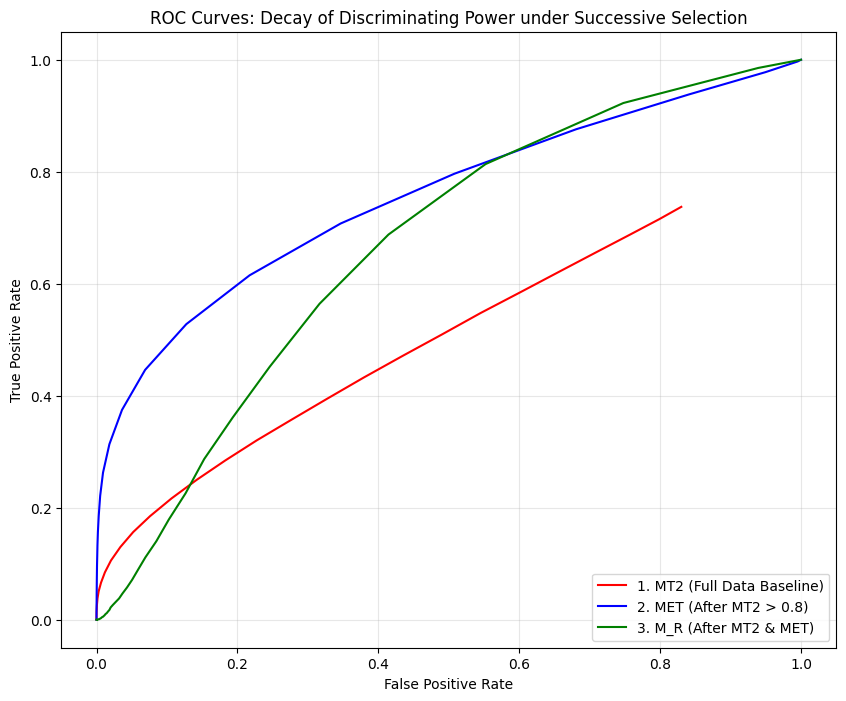

In [40]:
# 7.3: ROC after each successive selection step
# Shows how much discriminating power each variable has left
# after the previous cuts have already cleaned up the sample.

plt.figure(figsize=(10, 8))

# Step 1: MT2 on the full dataset
xc1, tpr1, fpr1 = calculate_efficiencies(df_sig, df_bkg, "MT2", 1)
plt.plot(fpr1, tpr1, color='red', label="1. MT2 (Full Data Baseline)")

# Step 2: MET on events that survived the MT2 cut
sig_step2 = df_sig[df_sig.MT2 > 0.8]
bkg_step2 = df_bkg[df_bkg.MT2 > 0.8]
xc2, tpr2, fpr2 = calculate_efficiencies(sig_step2, bkg_step2, "MET", 1)
plt.plot(fpr2, tpr2, color='blue', label="2. MET (After MT2 > 0.8)")

# Step 3: M_R on events that survived both previous cuts
sig_step3 = sig_step2[sig_step2.MET > 1.25]
bkg_step3 = bkg_step2[bkg_step2.MET > 1.25]
xc3, tpr3, fpr3 = calculate_efficiencies(sig_step3, bkg_step3, "M_R", 1)
plt.plot(fpr3, tpr3, color='green', label="3. M_R (After MT2 & MET)")

plt.title("ROC Curves: Decay of Discriminating Power under Successive Selection")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

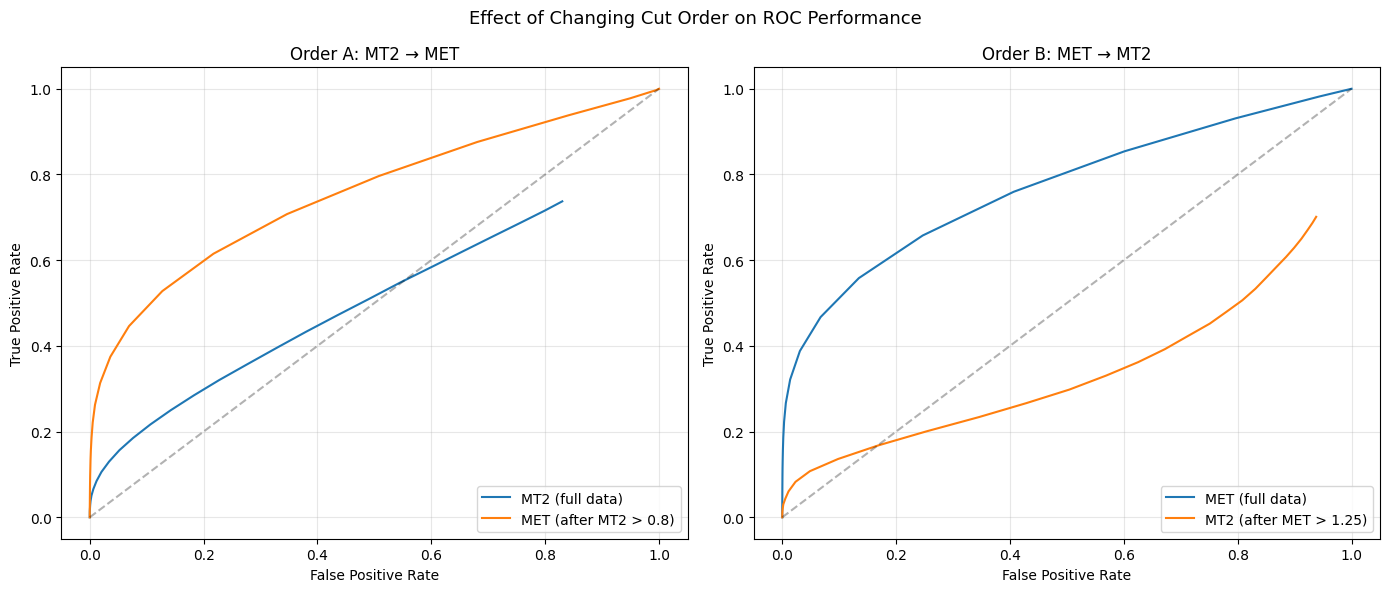

In [41]:
# 7.4: Effect of changing the order of successive selections
# Order A: MT2 first, then MET
# Order B: MET first, then MT2

plt.figure(figsize=(14, 6))

# --- Order A ---
plt.subplot(1, 2, 1)
xc_a1, tpr_a1, fpr_a1 = calculate_efficiencies(df_sig, df_bkg, "MT2", 1)
plt.plot(fpr_a1, tpr_a1, label="MT2 (full data)")

sig_a = df_sig[df_sig.MT2 > 0.8]
bkg_a = df_bkg[df_bkg.MT2 > 0.8]
xc_a2, tpr_a2, fpr_a2 = calculate_efficiencies(sig_a, bkg_a, "MET", 1)
plt.plot(fpr_a2, tpr_a2, label="MET (after MT2 > 0.8)")

plt.plot([0, 1], [0, 1], 'k--', alpha=0.3)
plt.title("Order A: MT2 → MET")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

# --- Order B ---
plt.subplot(1, 2, 2)
xc_b1, tpr_b1, fpr_b1 = calculate_efficiencies(df_sig, df_bkg, "MET", 1)
plt.plot(fpr_b1, tpr_b1, label="MET (full data)")

sig_b = df_sig[df_sig.MET > 1.25]
bkg_b = df_bkg[df_bkg.MET > 1.25]
xc_b2, tpr_b2, fpr_b2 = calculate_efficiencies(sig_b, bkg_b, "MT2", 1)
plt.plot(fpr_b2, tpr_b2, label="MT2 (after MET > 1.25)")

plt.plot([0, 1], [0, 1], 'k--', alpha=0.3)
plt.title("Order B: MET → MT2")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

plt.suptitle("Effect of Changing Cut Order on ROC Performance", fontsize=13)
plt.tight_layout()
plt.show()

Exercise 7.3 visually confirms the significance drop seen in the cut-flow table, the ROC curve for `M_R` flattens toward the diagonal after the first two cuts, showing that its unique discriminating power was absorbed by the correlated earlier cuts.

The random baseline is included on every plot as a clear reference for what random guessing looks like.

## Exercise 8: Linear Discriminant

### Exercise 8.1

Using numpy, compute the between-class $\bf{S}_B$ and within-class $\bf{S}_W$ covariance matrices defined as:

$$
\bf{S}_B = (\bf{m_2}-\bf{m_1})(\bf{m_2}-\bf{m_1})^T \\
$$
$$
\bf{S}_W = \sum_{i=1,2} \sum_{n=1}^{l_i} (\bf{x}_n^i - \bf{m}_i) (\bf{x}_n^i - \bf{m}_i)^T
$$

where $\bf{m_i}$ are the vectors containing the means for category 1 and 2, here defined as signal and background. Here $\bf{x}_n^i$ is the vector containing the observables for the $n$th example event in category $i$.

### Exercise 8.1

Compute the linear coefficients $\bf{w} = \bf{S_W}^{-1}(\bf{m_2}-\bf{m_1})$. Compare the histogram of the distribution of $F_n^i=\bf{w}^T\bf{x}_n^i$ for the two categories.

### Exercise 8.1

Draw the ROC curve for $F_n$. 

### Exercise 8.1

What is the maximal significance you can obtain in the scenarios in exercise 5? 

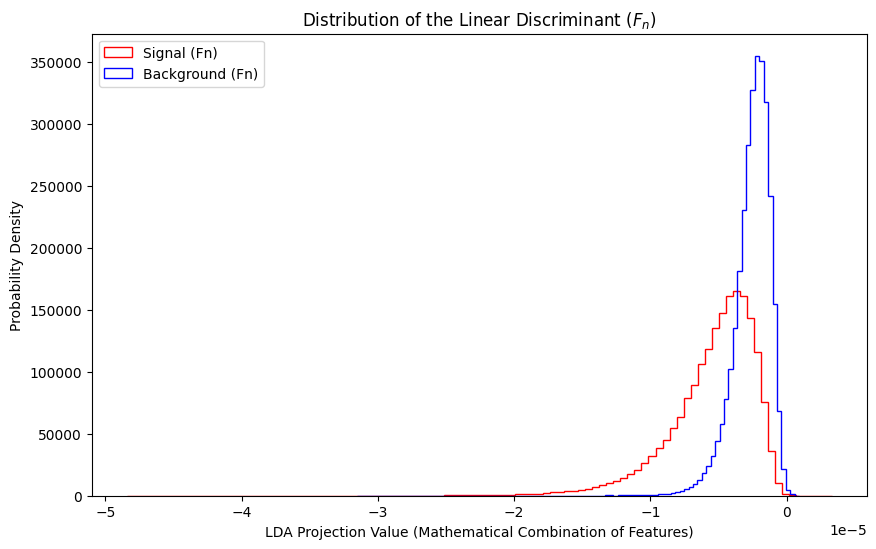

In [42]:
# Exercise 8.1 & 8.2
import numpy as np

# Using the high-level features since they carry the most physics information
X_sig = df_sig[FeatureNames].values
X_bkg = df_bkg[FeatureNames].values

# Mean vectors for each class
m1 = np.mean(X_sig, axis=0)
m2 = np.mean(X_bkg, axis=0)

# Within-class scatter matrix: scaled covariance summed over both classes
Sw = (len(X_sig) - 1) * np.cov(X_sig.T) + (len(X_bkg) - 1) * np.cov(X_bkg.T)

# Solve Sw * w = (m2 - m1) — more stable than inverting Sw directly
w = np.linalg.solve(Sw, (m2 - m1))

# Project all events onto the discriminant axis
df['Fn'] = df[FeatureNames].dot(w)

plt.figure(figsize=(10, 6))
plt.hist(df[df.signal == 1]['Fn'], bins=100, histtype="step",
         color="red",  label="Signal (Fn)",     density=True)
plt.hist(df[df.signal == 0]['Fn'], bins=100, histtype="step",
         color="blue", label="Background (Fn)",  density=True)
plt.title("Distribution of the Linear Discriminant ($F_n$)")
plt.xlabel("LDA Projection Value (Mathematical Combination of Features)")
plt.ylabel("Probability Density")
plt.legend()
plt.show()

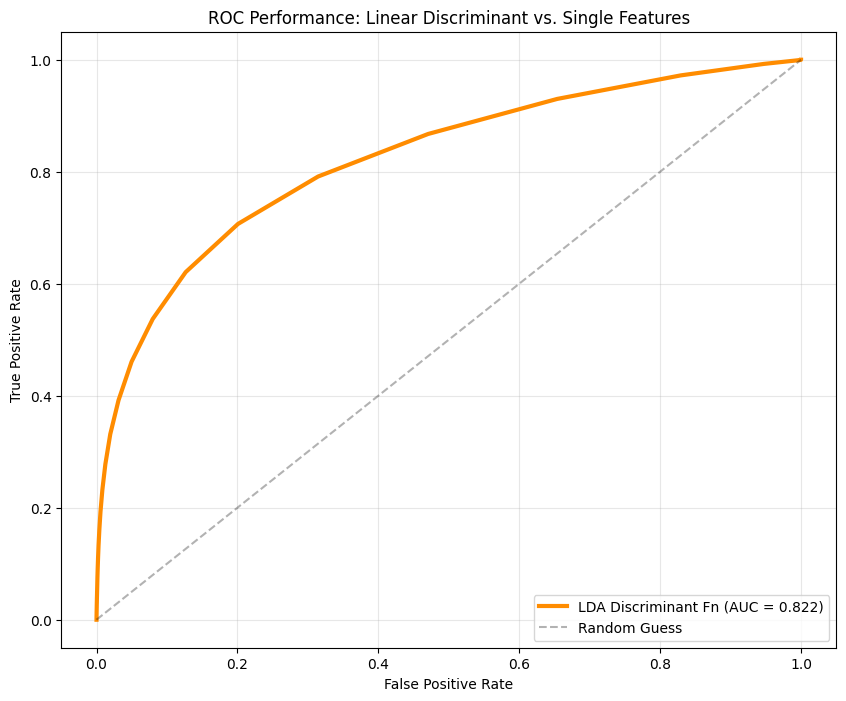

In [43]:
# Exercise 8.3: ROC curve for Fn

# Check which direction the signal sits so we set the right cut direction
fn_sig_mean = df[df.signal == 1]['Fn'].mean()
fn_bkg_mean = df[df.signal == 0]['Fn'].mean()
dir_fn = 1 if fn_sig_mean > fn_bkg_mean else -1
cut_directions['Fn'] = dir_fn

plt.figure(figsize=(10, 8))

xc_fn, tpr_fn, fpr_fn = calculate_efficiencies(
    df[df.signal == 1], df[df.signal == 0], 'Fn', dir_fn
)

try:
    auc_fn = np.abs(np.trapezoid(tpr_fn, fpr_fn))
except AttributeError:
    auc_fn = np.abs(np.trapz(tpr_fn, fpr_fn))

plt.plot(fpr_fn, tpr_fn, color='darkorange', linewidth=3,
         label=f"LDA Discriminant Fn (AUC = {auc_fn:.3f})")
plt.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random Guess')

plt.title("ROC Performance: Linear Discriminant vs. Single Features")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

In [44]:
# Exercise 8.4: Maximum significance achievable with Fn for each scenario
scenarios = [
    {"Ns": 10,    "Nb": 100},
    {"Ns": 100,   "Nb": 1000},
    {"Ns": 1000,  "Nb": 10000},
    {"Ns": 10000, "Nb": 100000}
]

print(f"{'Experimental Scenario':<25} | {'Max Significance (Sigma)':<25}")
print("-" * 55)

for s in scenarios:
    Ns_val, Nb_val = s["Ns"], s["Nb"]
    Ns_prime  = tpr_fn * Ns_val
    Nb_prime  = fpr_fn * Nb_val
    sig_curve = Ns_prime / np.sqrt(Ns_prime + Nb_prime + 1e-10)
    max_sig   = np.max(sig_curve)
    print(f"Ns={Ns_val:<5}, Nb={Nb_val:<8} | {max_sig:<25.2f}")

Experimental Scenario     | Max Significance (Sigma) 
-------------------------------------------------------
Ns=10   , Nb=100      | 1.49                     
Ns=100  , Nb=1000     | 4.71                     
Ns=1000 , Nb=10000    | 14.88                    
Ns=10000, Nb=100000   | 47.06                    


By computing the within-class scatter matrix `Sw` and the class mean vectors manually, I found the weight vector `w` that rotates the 10-dimensional feature space onto a single axis where signal and background are most separated. I used `np.linalg.solve` instead of inverting `Sw` directly because it is more numerically stable for large matrices. The resulting `Fn` combines all high-level features into one discriminant score, and its ROC curve and maximum significance can be compared directly against the single-variable results from Exercise 5.